In [1]:
import torch
from models.gpt2_masks import CircuitDiscoveryGPT2, PruningConfig
from transformers import GPT2LMHeadModel, GPT2Tokenizer
# --- Configuration ---
MODEL_NAME = "gpt2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Define a pruning config for a perfect 1-to-1 test
# Gates are initialized to 1.0, and all sparsity penalties are off.
pruning_config_for_test = PruningConfig(
    init_value=1.0,
    lambda_attention=0.5,
    lambda_mlp=0.5,
    lambda_component=0.5,
    lambda_block=0.5,
)

# --- Model Initialization ---
print("--- Initializing Models ---")

# Use the NEW custom constructor for the prunable model
model = CircuitDiscoveryGPT2.from_pretrained_with_pruning(
    MODEL_NAME,
    pruning_config=pruning_config_for_test
).to(DEVICE).eval()

# Load the standard base model for comparison
base_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
# --- Tokenizer Initialization ---
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("--- Tokenizer Initialized ---")

--- Initializing Models ---
--- Tokenizer Initialized ---


In [6]:
# Import necessary libraries
from tqdm import tqdm
from typing import List, Dict
def test_ioi_circuit(model: CircuitDiscoveryGPT2, tokenizer: GPT2Tokenizer, test_data: List[Dict], device: str):
    """
    Tests the pruned model's ability to perform the IOI task on unseen examples.

    Args:
        model: The trained and masked model.
        tokenizer: The tokenizer.
        test_data: A list of dictionaries, each with 'prompt' and 'completion'.
        device: The device to run inference on.
    """
    print("\n" + "="*50)
    print("      PERFORMING INFERENCE ON THE PRUNED CIRCUIT")
    print("="*50 + "\n")
    
    model.eval() # Set the model to evaluation mode
    model.to(device)

    correct_predictions = 0
    total_predictions = len(test_data)

    with torch.no_grad(): # Disable gradient calculations for inference
        for i, item in enumerate(tqdm(test_data, desc="Testing Circuit")):
            prompt = item['prompt']
            expected_completion = item['completion']

            inputs = tokenizer(prompt, return_tensors='pt').to(device)
            
            # Generate completion. max_new_tokens is short since we only expect a name.
            output_sequences = model.generate(
                input_ids=inputs['input_ids'],
                max_new_tokens=6,
                pad_token_id=tokenizer.eos_token_id, # Suppress padding warning
                early_stopping=True
            )

            # Decode only the newly generated tokens
            generated_ids = output_sequences[0][inputs['input_ids'].shape[-1]:]
            generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

            # Check for correctness
            is_correct = generated_text.startswith(expected_completion)
            if is_correct:
                correct_predictions += 1
            
            # Print a few examples to see the output
            if i < 5 or not is_correct: # Print first 5 and any incorrect ones
                print(f"\nPrompt:      '{prompt}'")
                print(f"Expected:    '{expected_completion}'")
                print(f"Generated:   '{generated_text}'")
                print(f"Result:      {'✅ CORRECT' if is_correct else '❌ INCORRECT'}")

    accuracy = (correct_predictions / total_predictions) * 100
    print("\n" + "="*50)
    print(f"Circuit Performance Summary:")
    print(f"Correct Predictions: {correct_predictions} / {total_predictions}")
    print(f"Accuracy on IOI task: {accuracy:.2f}%")
    print("="*50)

Device: cuda
Total Model Parameters: 124.48M
Trainable Gate Parameters: 37044 (0.0298% of total)
Starting training...


Epoch 1/5: 100%|██████████| 125/125 [00:07<00:00, 16.67it/s]


Epoch 1 Summary: Avg Data Loss: 0.5483, Avg Sparsity Loss: 20.5833


Epoch 2/5: 100%|██████████| 125/125 [00:06<00:00, 18.22it/s]


Epoch 2 Summary: Avg Data Loss: 0.0341, Avg Sparsity Loss: 6.7755


...

Epoch 3 Summary: Avg Data Loss: 0.0264, Avg Sparsity Loss: 1.5262


Epoch 4/5: 100%|██████████| 125/125 [00:06<00:00, 18.10it/s]


Epoch 4 Summary: Avg Data Loss: 0.0205, Avg Sparsity Loss: 0.7655


Epoch 5/5: 100%|██████████| 125/125 [00:06<00:00, 18.08it/s]
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_to_plot, ax=ax, palette=palette)
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_to_plot, ax=ax, palette=palette)
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_

Epoch 5 Summary: Avg Data Loss: 0.0187, Avg Sparsity Loss: 0.5329

Applying final circuit mask...
  Block 0 Attention Heads: 12/12 active
  Block 1 Attention Heads: 7/12 active
  Block 2 Attention Heads: 6/12 active
  Block 3 Attention Heads: 0/12 active
  Block 4 Attention Heads: 5/12 active
  Block 5 Attention Heads: 0/12 active
  Block 6 Attention Heads: 4/12 active
  Block 7 Attention Heads: 8/12 active
  Block 8 Attention Heads: 5/12 active
  Block 9 Attention Heads: 12/12 active
  Block 10 Attention Heads: 12/12 active
  Block 11 Attention Heads: 12/12 active


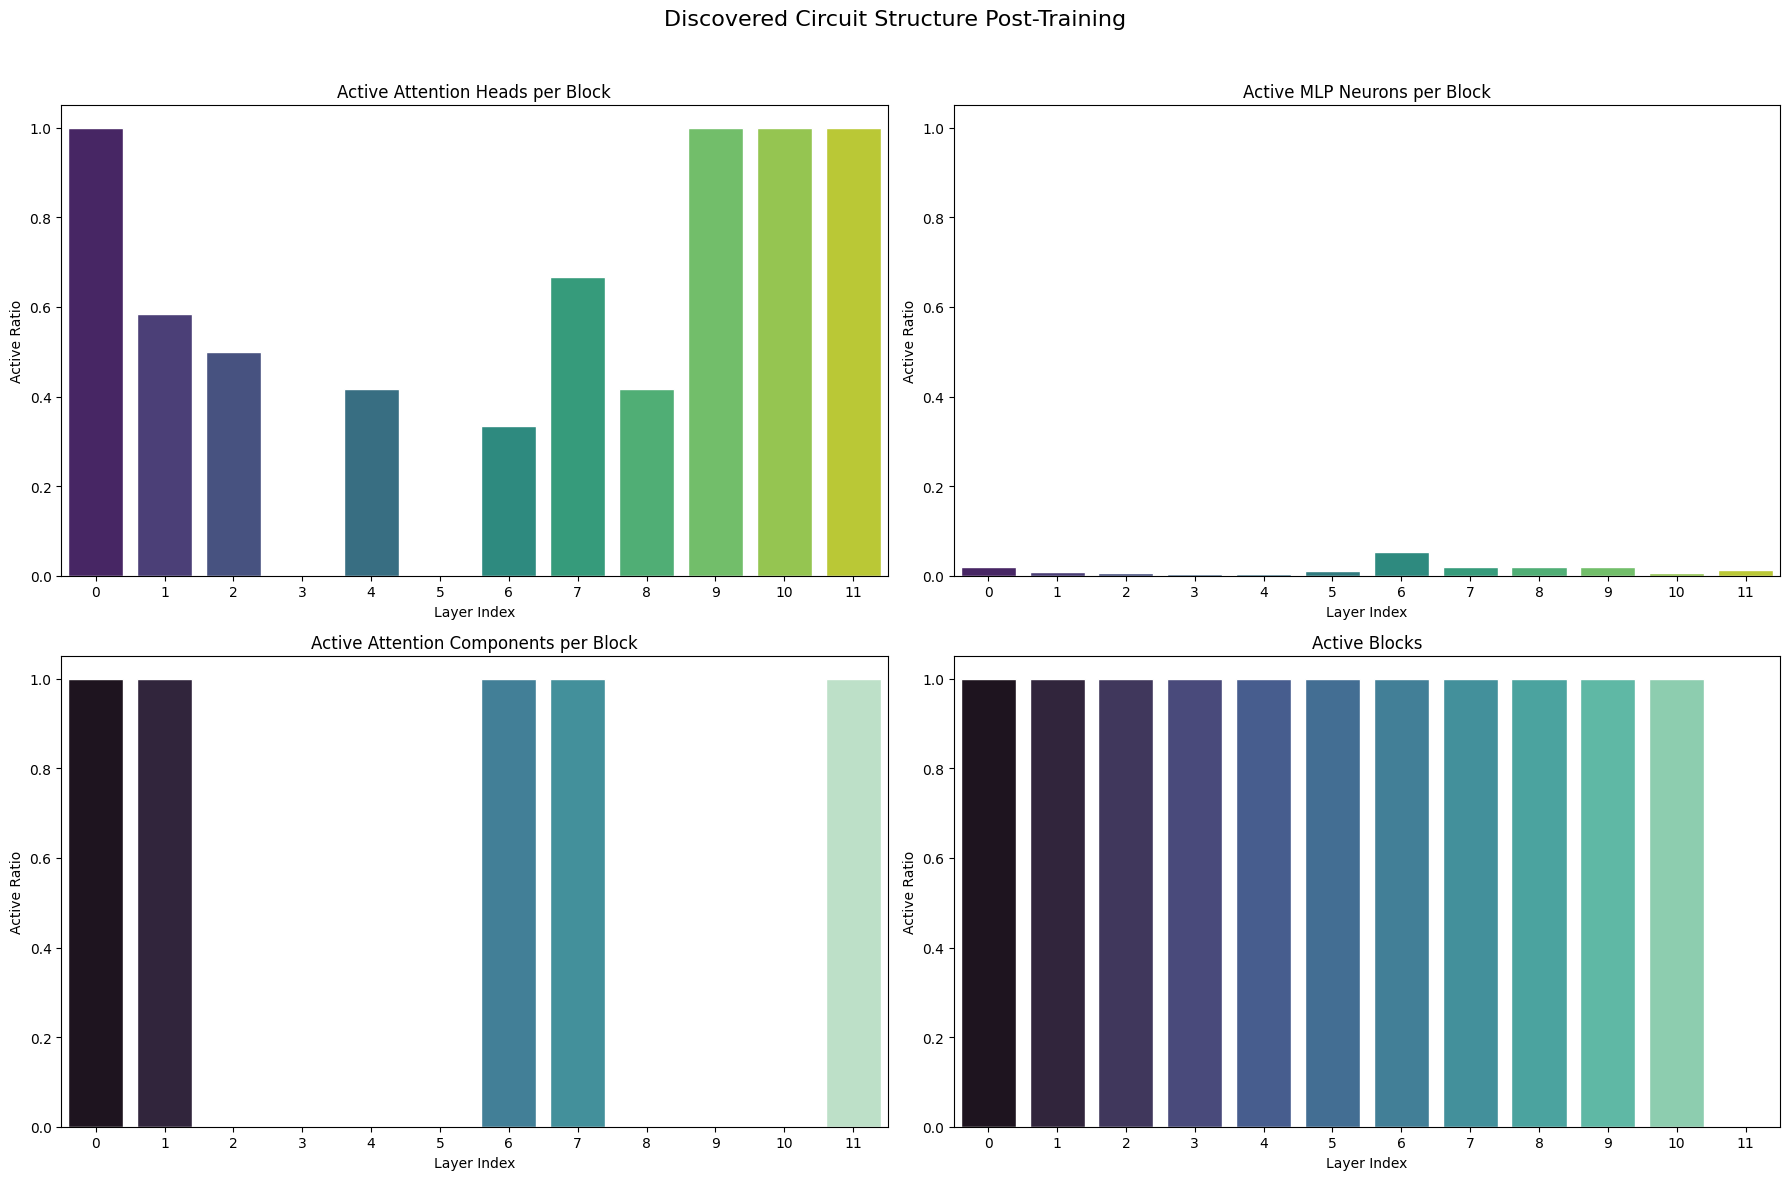

In [3]:
from dataset.ioi import IOIDataset, generate_ioi_sample
from torch.utils.data import DataLoader
from trainers.gpt2 import CircuitTrainer
from torch.optim import AdamW
if __name__ == '__main__':
    # --- Configuration ---
    MODEL_NAME = 'gpt2'
    NUM_EPOCHS = 5
    LEARNING_RATE = 1e-2 # Higher learning rate for gates is often effective
    BATCH_SIZE = 16
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # --- Setup Model and Tokenizer ---
    pruning_config = PruningConfig()
    model = CircuitDiscoveryGPT2.from_pretrained_with_pruning(MODEL_NAME, pruning_config)
    tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
    model.to(DEVICE)

    # --- Freeze Backbone, Isolate Gate Parameters ---
    gate_params = []
    total_params = 0
    for name, param in model.named_parameters():
        total_params += param.numel()
        if 'gate' in name:
            gate_params.append(param)
            param.requires_grad = True # Ensure gates are trainable
        else:
            param.requires_grad = False # Freeze all other parameters

    trainable_params = sum(p.numel() for p in gate_params)
    print(f"Device: {DEVICE}")
    print(f"Total Model Parameters: {total_params / 1e6:.2f}M")
    print(f"Trainable Gate Parameters: {trainable_params} ({(trainable_params / total_params) * 100:.4f}% of total)")

    # --- Setup Optimizer ---
    optimizer = AdamW(gate_params, lr=LEARNING_RATE)

    # --- Prepare Dataset ---
    names = ["Mary", "John", "Alice", "Bob", "Patricia", "James", "Linda", "Robert"]
    locations = ["store", "park", "cafe", "office", "school", "hospital"]
    objects = ["drink", "book", "gift", "letter", "key", "report"]
    
    # Generate a larger dataset for more stable training
    ioi_data = [generate_ioi_sample(names, locations, objects) for _ in range(2000)]
    ioi_dataset = IOIDataset(ioi_data, tokenizer)
    train_dataloader = DataLoader(ioi_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # --- Train the Circuit ---
    trainer = CircuitTrainer(model, tokenizer, device=DEVICE)
    trainer.train(train_dataloader, optimizer, num_epochs=NUM_EPOCHS)

    # --- Analyze the Result ---
    model.apply_circuit_mask(verbose=True)
    trainer.visualize_circuit_stats()


Device: cuda
Total Model Parameters: 124.48M
Trainable Gate Parameters: 37044 (0.0298% of total)
Starting training...


Epoch 1/5: 100%|██████████| 125/125 [00:06<00:00, 18.22it/s]


Epoch 1 Summary: Avg Data Loss: 0.5290, Avg Sparsity Loss: 20.6689


Epoch 2/5: 100%|██████████| 125/125 [00:06<00:00, 18.18it/s]


Epoch 2 Summary: Avg Data Loss: 0.0275, Avg Sparsity Loss: 6.8800


...

Epoch 3 Summary: Avg Data Loss: 0.0239, Avg Sparsity Loss: 1.5303


Epoch 4/5: 100%|██████████| 125/125 [00:06<00:00, 18.10it/s]


Epoch 4 Summary: Avg Data Loss: 0.0208, Avg Sparsity Loss: 0.8012


Epoch 5/5: 100%|██████████| 125/125 [00:07<00:00, 17.71it/s]
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_to_plot, ax=ax, palette=palette)
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_to_plot, ax=ax, palette=palette)
/mounts/u-amo-d1/grad/mha361/work/circuits/trainers/gpt2.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(layer_indices), y=data_

Epoch 5 Summary: Avg Data Loss: 0.0177, Avg Sparsity Loss: 0.5370

Applying final circuit mask...
  Block 0 Attention Heads: 12/12 active
  Block 1 Attention Heads: 8/12 active
  Block 2 Attention Heads: 7/12 active
  Block 3 Attention Heads: 0/12 active
  Block 4 Attention Heads: 7/12 active
  Block 5 Attention Heads: 1/12 active
  Block 6 Attention Heads: 6/12 active
  Block 7 Attention Heads: 10/12 active
  Block 8 Attention Heads: 6/12 active
  Block 9 Attention Heads: 12/12 active
  Block 10 Attention Heads: 12/12 active
  Block 11 Attention Heads: 12/12 active


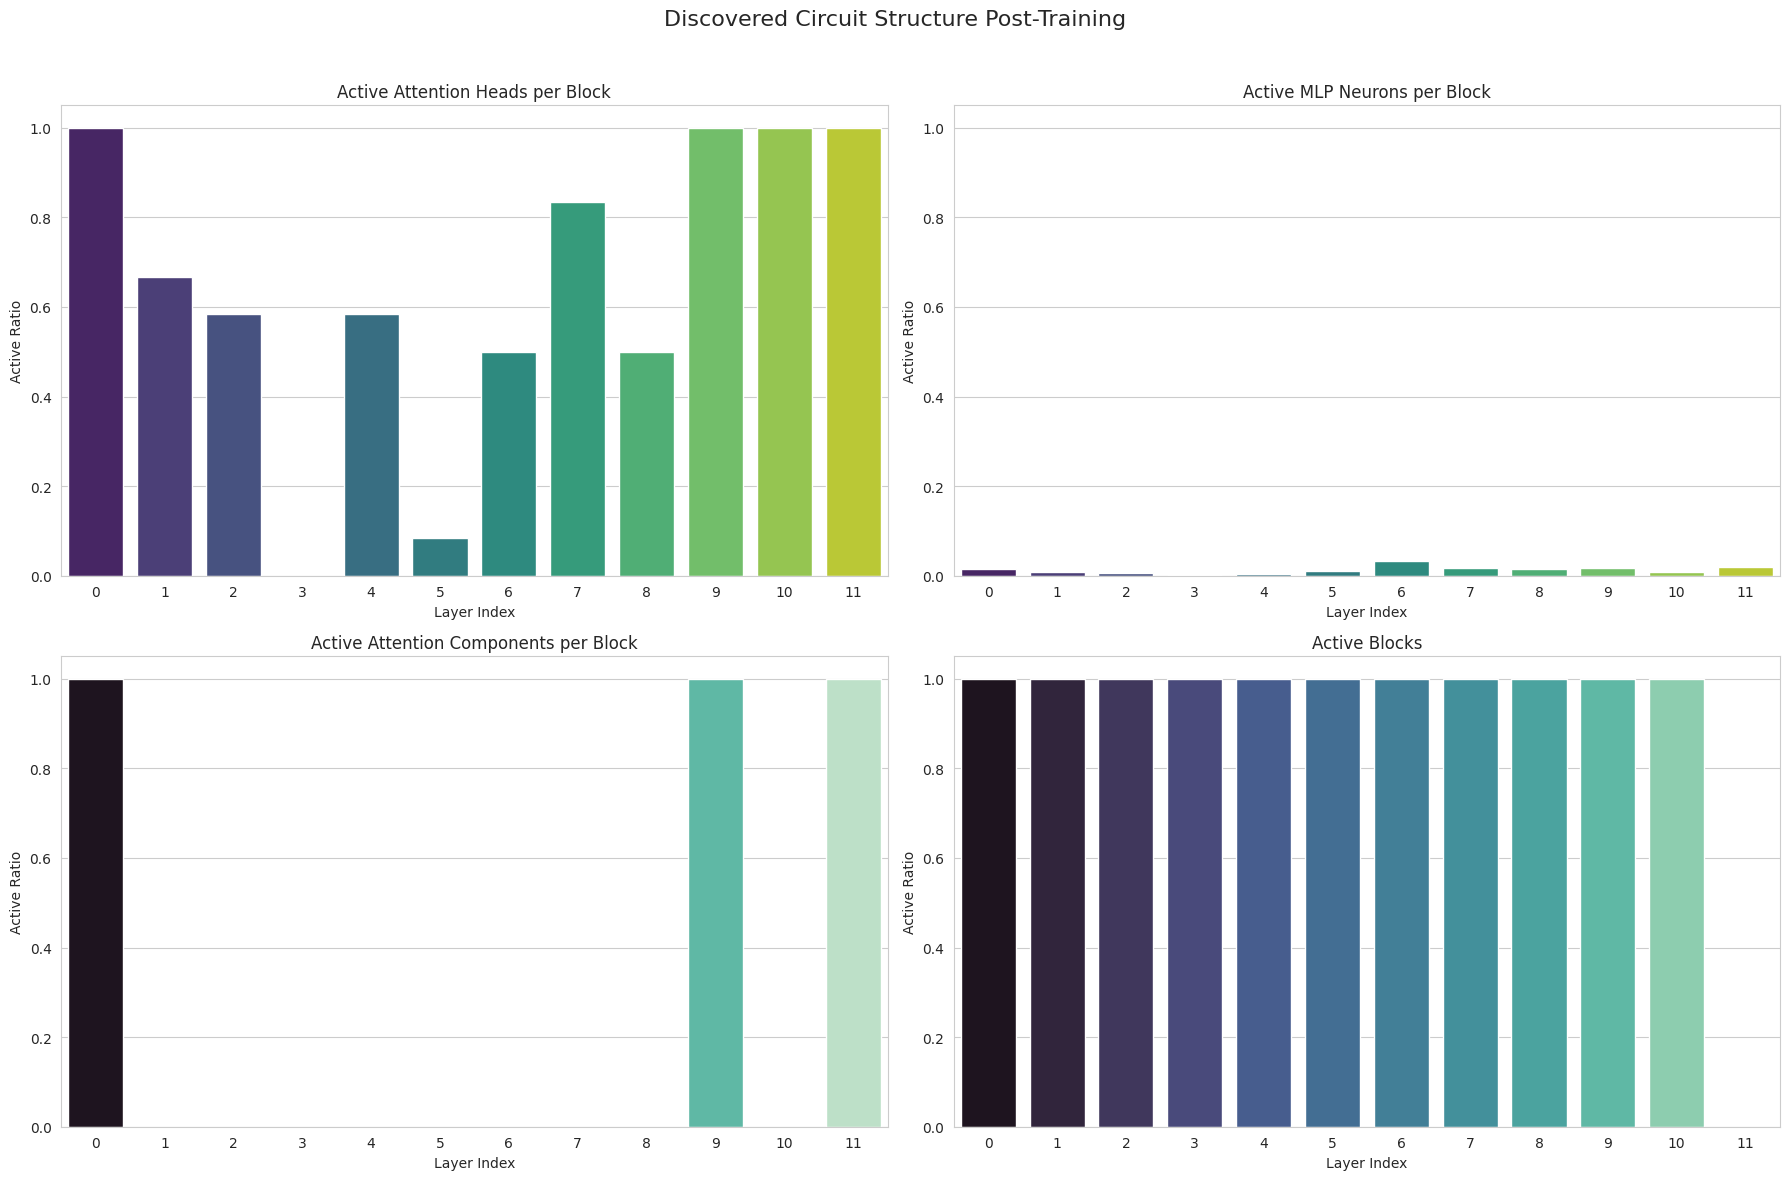


Generating a new set of unseen samples for testing...

      PERFORMING INFERENCE ON THE PRUNED CIRCUIT



Testing Circuit:   0%|          | 0/50 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for 


Prompt:      'When John and Robert went to the hospital, Robert gave a gift to'
Expected:    'John'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Mary and Patricia went to the office, Patricia gave a drink to'
Expected:    'Mary'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Bob and Linda went to the store, Linda gave a letter to'
Expected:    'Bob'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Alice and Bob went to the hospital, Bob gave a letter to'
Expected:    'Alice'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Bob and Alice went to the school, Alice gave a key to'
Expected:    'Bob'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Patricia and James went to the store, James gave a book to'
Expected:    'Patricia'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Mary and Patricia went to the park, Patricia gave a drink to'
Expected:    'Mary'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:     

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Testing Circuit:  32%|███▏      | 16/50 [00:00<00:00, 74.85it/s]The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Prompt:      'When Mary and Linda went to the cafe, Linda gave a gift to'
Expected:    'Mary'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Mary and Alice went to the cafe, Alice gave a gift to'
Expected:    'Mary'
Generated:   ''
Result:      ❌ INCORRECT


...

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Testing Circuit:  96%|█████████▌| 48/50 [00:00<00:00, 77.99it/s]The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Prompt:      'When Linda and James went to the hospital, James gave a drink to'
Expected:    'Linda'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When Alice and James went to the cafe, James gave a book to'
Expected:    'Alice'
Generated:   ''
Result:      ❌ INCORRECT


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Testing Circuit: 100%|██████████| 50/50 [00:00<00:00, 77.29it/s]


Prompt:      'When John and Bob went to the store, Bob gave a gift to'
Expected:    'John'
Generated:   ''
Result:      ❌ INCORRECT

Prompt:      'When John and James went to the office, James gave a gift to'
Expected:    'John'
Generated:   ''
Result:      ❌ INCORRECT

Circuit Performance Summary:
Correct Predictions: 0 / 50
Accuracy on IOI task: 0.00%


: 

In [ ]:
# ==============================================================================
# 4. MAIN EXECUTION (Updated)
# ==============================================================================

if __name__ == '__main__':
    # --- Configuration ---
    MODEL_NAME = 'gpt2'
    NUM_EPOCHS = 5
    LEARNING_RATE = 1e-2 
    BATCH_SIZE = 16
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # --- Setup Model and Tokenizer ---
    pruning_config = PruningConfig()
    model = CircuitDiscoveryGPT2.from_pretrained_with_pruning(MODEL_NAME, pruning_config)
    tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token # Set pad token for batching
    model.to(DEVICE)

    # --- Freeze Backbone, Isolate Gate Parameters ---
    gate_params = []
    total_params = 0
    for name, param in model.named_parameters():
        total_params += param.numel()
        if 'gate' in name:
            gate_params.append(param)
            param.requires_grad = True 
        else:
            param.requires_grad = False 

    trainable_params = sum(p.numel() for p in gate_params)
    print(f"Device: {DEVICE}")
    print(f"Total Model Parameters: {total_params / 1e6:.2f}M")
    print(f"Trainable Gate Parameters: {trainable_params} ({(trainable_params / total_params) * 100:.4f}% of total)")

    # --- Setup Optimizer ---
    optimizer = AdamW(gate_params, lr=LEARNING_RATE)

    # --- Prepare Dataset ---
    names = ["Mary", "John", "Alice", "Bob", "Patricia", "James", "Linda", "Robert"]
    locations = ["store", "park", "cafe", "office", "school", "hospital"]
    objects = ["drink", "book", "gift", "letter", "key", "report"]
    
    ioi_data = [generate_ioi_sample(names, locations, objects) for _ in range(2000)]
    ioi_dataset = IOIDataset(ioi_data, tokenizer)
    train_dataloader = DataLoader(ioi_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # --- Train the Circuit ---
    trainer = CircuitTrainer(model, tokenizer, device=DEVICE)
    trainer.train(train_dataloader, optimizer, num_epochs=NUM_EPOCHS)

    # --- Analyze the Result ---
    model.apply_circuit_mask(verbose=True)
    trainer.visualize_circuit_stats()
    
    # =======================================================================
    # NEW: Test the pruned circuit on unseen data
    # =======================================================================
    
    # Generate a fresh, unseen test set
    print("\nGenerating a new set of unseen samples for testing...")
    ioi_test_data = [generate_ioi_sample(names, locations, objects) for _ in range(50)]

    # Run the inference test
    test_ioi_circuit(model, tokenizer, ioi_test_data, DEVICE)

In [1]:
import torch
torch.nn.Sigmoid(-100)

TypeError: Sigmoid.__init__() takes 1 positional argument but 2 were given

In [2]:
import random

# Define components for sentence generation
names = ["Mary", "John", "Alice", "Bob", "Patricia", "James", "Linda", "Robert"]
locations = ["store", "park", "cafe", "office", "school", "hospital"]
objects = ["drink", "book", "gift", "letter", "key", "report"]

def generate_ioi_sample(names_list, locations_list, objects_list):
    # Ensure at least two distinct names
    if len(names_list) < 2:
        raise ValueError("Need at least two names for IOI.")
    s_name, io_name = random.sample(names_list, 2) # Subject and Indirect Object

    # Randomly choose who gives the object
    giver = s_name
    receiver = io_name
    # Or, to make it more robust, sometimes flip them
    # if random.random() < 0.5:
    #     giver, receiver = receiver, giver

    loc = random.choice(locations_list)
    obj = random.choice(objects_list)

    # Template: "When [IO_Name] and [S_Name] went to the [Location], [S_Name] gave a [Object] to "
    # The model should predict [IO_Name]
    # More robust template from the paper:
    # "[S_Name] and [IO_Name] went to the [Location]. Then [S_Name] gave a [Object] to" -> [IO_Name]
    # Let's use a common one:
    # sentence_prompt = f"{s_name} and {io_name} went to the {loc}. Then {s_name} gave the {obj} to"
    # For your example: "When Mary and John went to the store, John gave a drink to " -> Mary
    # Here, John is S, Mary is IO.
    # Let's call them Name1 and Name2.
    name1, name2 = random.sample(names_list, 2)
    location = random.choice(locations_list)
    obj_item = random.choice(objects_list)

    # Scenario 1: Name2 is the IO
    # "When Name1 and Name2 went to the location, Name1 gave an object to" -> Name2
    # Scenario 2: Name1 is the IO
    # "When Name1 and Name2 went to the location, Name2 gave an object to" -> Name1

    # For your specific example: "When Mary and John went to the store, John gave a drink to "
    # Here, Mary is the IO (the one *not* giving). John is S (the giver).
    # Let's use distinct terms: giver_name, receiver_name
    giver_name, receiver_name = random.sample(names_list, 2)

    prompt = f"When {receiver_name} and {giver_name} went to the {location}, {giver_name} gave a {obj_item} to"
    correct_completion = receiver_name # The model should predict the receiver_name

    # Alternative template (simpler, often used)
    # prompt = f"{giver_name} and {receiver_name} went to the {location}. {giver_name} gave the {obj_item} to"
    # correct_completion = receiver_name

    return {
        "prompt": prompt,
        "target_S": giver_name,  # Subject / Giver
        "target_IO": receiver_name, # Indirect Object / Receiver
        "full_sentence_for_completion": f"{prompt} {receiver_name}."
    }

# Generate a few samples
ioi_dataset = [generate_ioi_sample(names, locations, objects) for _ in range(100)] # Create 100 samples

# Example:
sample = ioi_dataset[0]
print(f"Prompt: '{sample['prompt']}'")
print(f"Expected IO: '{sample['target_IO']}'")
print(f"Giver (S): '{sample['target_S']}'")

Prompt: 'When John and Robert went to the school, Robert gave a gift to'
Expected IO: 'John'
Giver (S): 'Robert'


In [4]:
from datasets import load_dataset

ds = load_dataset("fahamu/ioi")

In [5]:
ds['train'][0]

{'ioi_sentences': 'Friends Juana and Kristi found a mango at the bar. Kristi gave it to Juana'}

In [3]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = base_model
model.to(device)  # Ensure the model is on the correct device
base_model.to(device)  # Ensure the base model is also on the correct device
def get_ioi_predictions(model, tokenizer, ioi_sample, device):
    prompt_text = ioi_sample['prompt']
    # Tokenize the prompt. Ensure it ends with a space if the names are separate words.
    # For names like "Mary", they are often single tokens.
    # If the prompt is "John gave a drink to", the next token should be the first token of "Mary".
    # Many names are single tokens for GPT-2's tokenizer.
    # We might need to add a space at the end of the prompt to ensure the name is predicted as a whole word.
    # Or, handle multi-token names if necessary.
    if not prompt_text.endswith(" "):
        prompt_text += " "

    inputs = tokenizer(prompt_text, return_tensors='pt', padding=True).to(device)
    input_ids = inputs.input_ids

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs["logits"]

    # We care about the logits for the *next* token after the prompt
    next_token_logits = logits[0, -1, :] # Batch size 1, last token's logits

    # Get the token IDs for the target IO and S names
    # Add a leading space to tokenizer for names to match how they often appear after a space.
    target_io_token_id = tokenizer.encode(" " + ioi_sample['target_IO'], add_special_tokens=False)
    target_s_token_id = tokenizer.encode(" " + ioi_sample['target_S'], add_special_tokens=False)

    # Handle if names are multi-token (for simplicity, assume single token for now)
    # This is a simplification; robust IOI checks if the *first* token of the name is predicted.
    if len(target_io_token_id) == 0 or len(target_s_token_id) == 0:
        return {
            "prompt": prompt_text,
            "predicted_token_id": None,
            "predicted_token_str": "[ERROR: Empty token for name]",
            "logit_IO": -float('inf'),
            "logit_S": -float('inf'),
            "is_correct": False
        }

    target_io_token_id = target_io_token_id[0]
    target_s_token_id = target_s_token_id[0]


    logit_for_io = next_token_logits[target_io_token_id].item()
    logit_for_s = next_token_logits[target_s_token_id].item()

    # Get the predicted token
    predicted_token_id = torch.argmax(next_token_logits).item()
    predicted_token_str = tokenizer.decode(predicted_token_id)

    is_correct = (predicted_token_id == target_io_token_id)

    return {
        "prompt": prompt_text,
        "predicted_token_id": predicted_token_id,
        "predicted_token_str": predicted_token_str.strip(), # strip potential leading space
        "logit_IO": logit_for_io,
        "logit_S": logit_for_s,
        "is_correct": is_correct,
        "target_IO_token_id": target_io_token_id,
        "target_S_token_id": target_s_token_id
    }

# Example usage:
if len(ioi_dataset) > 0:
    print("Base_Model Sample Evaluation:")
    sample_result = get_ioi_predictions(base_model, tokenizer, ioi_dataset[0], device)
    print("\nIOI Sample Evaluation:")
    print(f"  Prompt: '{sample_result['prompt']}'")
    print(f"  Target IO: '{ioi_dataset[0]['target_IO']}' (Token ID: {sample_result['target_IO_token_id']})")
    print(f"  Target S (distractor): '{ioi_dataset[0]['target_S']}' (Token ID: {sample_result['target_S_token_id']})")
    print(f"  Predicted Token: '{sample_result['predicted_token_str']}' (ID: {sample_result['predicted_token_id']})")
    print(f"  Logit for Correct IO ({ioi_dataset[0]['target_IO']}): {sample_result['logit_IO']:.2f}")
    print(f"  Logit for S ({ioi_dataset[0]['target_S']}): {sample_result['logit_S']:.2f}")
    print(f"  Is correct (top prediction is IO)?: {sample_result['is_correct']}")
    
if len(ioi_dataset) > 0:
    print("Prunable Model Sample Evaluation:")
    sample_result = get_ioi_predictions(model, tokenizer, ioi_dataset[0], device)
    print("\nIOI Sample Evaluation:")
    print(f"  Prompt: '{sample_result['prompt']}'")
    print(f"  Target IO: '{ioi_dataset[0]['target_IO']}' (Token ID: {sample_result['target_IO_token_id']})")
    print(f"  Target S (distractor): '{ioi_dataset[0]['target_S']}' (Token ID: {sample_result['target_S_token_id']})")
    print(f"  Predicted Token: '{sample_result['predicted_token_str']}' (ID: {sample_result['predicted_token_id']})")
    print(f"  Logit for Correct IO ({ioi_dataset[0]['target_IO']}): {sample_result['logit_IO']:.2f}")
    print(f"  Logit for S ({ioi_dataset[0]['target_S']}): {sample_result['logit_S']:.2f}")
    print(f"  Is correct (top prediction is IO)?: {sample_result['is_correct']}")

Base_Model Sample Evaluation:

IOI Sample Evaluation:
  Prompt: 'When John and Robert went to the school, Robert gave a gift to '
  Target IO: 'John' (Token ID: 1757)
  Target S (distractor): 'Robert' (Token ID: 5199)
  Predicted Token: '' (ID: 1849)
  Logit for Correct IO (John): -70.30
  Logit for S (Robert): -70.08
  Is correct (top prediction is IO)?: False
Prunable Model Sample Evaluation:

IOI Sample Evaluation:
  Prompt: 'When John and Robert went to the school, Robert gave a gift to '
  Target IO: 'John' (Token ID: 1757)
  Target S (distractor): 'Robert' (Token ID: 5199)
  Predicted Token: '' (ID: 1849)
  Logit for Correct IO (John): -70.30
  Logit for S (Robert): -70.08
  Is correct (top prediction is IO)?: False


In [4]:
def evaluate_ioi_dataset(model, tokenizer, dataset, device):
    correct_predictions = 0
    total_predictions = len(dataset)
    logit_diffs = []
    all_results = []

    for sample in dataset:
        # Ensure names are in the tokenizer's vocabulary as single tokens (with leading space) for this simplified eval
        # A more robust check might be needed if names are multi-token or not perfectly tokenized
        io_token_ids = tokenizer.encode(" " + sample['target_IO'], add_special_tokens=False)
        s_token_ids = tokenizer.encode(" " + sample['target_S'], add_special_tokens=False)

        if not io_token_ids or not s_token_ids:
            print(f"Warning: Could not tokenize IO ('{sample['target_IO']}') or S ('{sample['target_S']}') properly. Skipping sample: {sample['prompt']}")
            total_predictions -=1 # Adjust total count
            continue


        result = get_ioi_predictions(model, tokenizer, sample, device)
        all_results.append(result)

        if result['is_correct']:
            correct_predictions += 1
        if result['logit_IO'] > -float('inf') and result['logit_S'] > -float('inf'): # Ensure valid logits
             logit_diffs.append(result['logit_IO'] - result['logit_S'])

    accuracy = (correct_predictions / total_predictions) * 100 if total_predictions > 0 else 0
    avg_logit_diff = sum(logit_diffs) / len(logit_diffs) if len(logit_diffs) > 0 else float('nan')

    return {
        "accuracy": accuracy,
        "average_logit_difference_IO_S": avg_logit_diff,
        "num_samples_evaluated": total_predictions,
        "individual_results": all_results
    }

# Run evaluation
ioi_eval_results = evaluate_ioi_dataset(model, tokenizer, ioi_dataset, device)
print("\n--- IOI Task Evaluation ---")
print(f"Accuracy: {ioi_eval_results['accuracy']:.2f}%")
print(f"Average Logit Difference (IO - S): {ioi_eval_results['average_logit_difference_IO_S']:.2f}")
print(f"Total samples evaluated: {ioi_eval_results['num_samples_evaluated']}")


--- IOI Task Evaluation ---
Accuracy: 0.00%
Average Logit Difference (IO - S): 0.33
Total samples evaluated: 100


In [5]:
def generate_greater_than_sample():
    start_year = random.randint(1000, 2025) # Full start year
    year_prefix = str(start_year)[:2] # First two digits (e.g., "17" from 1732)
    year_suffix_val = int(str(start_year)[2:]) # Last two digits as int (e.g., 32 from 1732)

    # Create a context sentence
    contexts = [
        "The treaty was signed from the year {start_year} to the year {year_prefix}",
        "It was effective from {start_year} until {year_prefix}",
        "The records span {start_year} through {year_prefix}",
        "The period lasted from the year {start_year} to the year {year_prefix}"
    ]
    prompt_template = random.choice(contexts)
    prompt = prompt_template.format(start_year=start_year, year_prefix=year_prefix)

    return {
        "prompt": prompt,
        "start_year": start_year,
        "year_prefix": year_prefix, # e.g. "17"
        "threshold_suffix": year_suffix_val # e.g. 32. The prediction must be > this.
    }

# Generate a dataset
greater_than_dataset = [generate_greater_than_sample() for _ in range(100)]

# Example:
sample_gt = greater_than_dataset[0]
print(f"Prompt: '{sample_gt['prompt']}'")
print(f"Start Year: {sample_gt['start_year']}")
print(f"Year Prefix (for prompt): '{sample_gt['year_prefix']}'")
print(f"Threshold Suffix (prediction must be > this): {sample_gt['threshold_suffix']}")

Prompt: 'It was effective from 1785 until 17'
Start Year: 1785
Year Prefix (for prompt): '17'
Threshold Suffix (prediction must be > this): 85


In [6]:
def get_greater_than_predictions(model, tokenizer, gt_sample, device, max_new_tokens=2):
    prompt_text = gt_sample['prompt']
    # Ensure the prompt ends with the prefix and potentially a space if needed
    # e.g., "... to the year 17"
    # The model should predict "33", "34", ... "99" for start_year 1732
    if not prompt_text.endswith(gt_sample['year_prefix']):
         # This should not happen if data gen is correct, but as a safeguard:
        print(f"Warning: Prompt '{prompt_text}' doesn't end with prefix '{gt_sample['year_prefix']}'")

    inputs = tokenizer(prompt_text, return_tensors='pt').to(device)

    # Generate the next two tokens
    # Using greedy decoding here. For more nuanced analysis, you might look at logits directly.
    outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id, # Stop if EOS is generated
        num_return_sequences=1,
        do_sample=False # Greedy
    )

    # Extract only the generated tokens
    generated_ids = outputs[0, inputs.input_ids.shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Try to parse the generated text as two digits
    predicted_suffix_str = ""
    predicted_suffix_val = -1 # Default to invalid
    is_valid_format = False # Was it two digits?

    # We expect two digits. Let's check the raw generated tokens for digits.
    digit_tokens = []
    current_num_str = ""

    for token_id in generated_ids:
        token_str = tokenizer.decode(token_id)
        # Check if the token string itself is a digit or part of a multi-digit number token
        if token_str.strip().isdigit():
            current_num_str += token_str.strip()
            if len(current_num_str) >= 2:
                break
        else: # if a non-digit is generated early, stop.
            break

    if len(current_num_str) == 2 and current_num_str.isdigit():
        predicted_suffix_str = current_num_str
        predicted_suffix_val = int(current_num_str)
        is_valid_format = True

    is_correct_greater_than = False
    if is_valid_format:
        is_correct_greater_than = (predicted_suffix_val > gt_sample['threshold_suffix'] and predicted_suffix_val <=99)

    return {
        "prompt": prompt_text,
        "start_year": gt_sample['start_year'],
        "threshold_suffix": gt_sample['threshold_suffix'],
        "generated_text_full": generated_text,
        "predicted_suffix_str": predicted_suffix_str, # The two digits like "35"
        "predicted_suffix_val": predicted_suffix_val, # The integer value like 35
        "is_valid_two_digit_format": is_valid_format,
        "is_correct_greater_than": is_correct_greater_than
    }


# Example usage:
if len(greater_than_dataset) > 0:
    sample_gt_result = get_greater_than_predictions(model, tokenizer, greater_than_dataset[0], device)
    print("\nGreater-Than Sample Evaluation:")
    print(f"  Prompt: '{sample_gt_result['prompt']}'")
    print(f"  Start Year: {sample_gt_result['start_year']}")
    print(f"  Threshold Suffix: > {sample_gt_result['threshold_suffix']}")
    print(f"  Generated Text (raw): '{sample_gt_result['generated_text_full']}'")
    print(f"  Predicted Suffix (parsed): '{sample_gt_result['predicted_suffix_str']}' (Value: {sample_gt_result['predicted_suffix_val']})")
    print(f"  Is valid two-digit format?: {sample_gt_result['is_valid_two_digit_format']}")
    print(f"  Is correct (prediction > threshold)?: {sample_gt_result['is_correct_greater_than']}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Greater-Than Sample Evaluation:
  Prompt: 'It was effective from 1785 until 17'
  Start Year: 1785
  Threshold Suffix: > 85
  Generated Text (raw): '90,'
  Predicted Suffix (parsed): '90' (Value: 90)
  Is valid two-digit format?: True
  Is correct (prediction > threshold)?: True


In [ ]:
def evaluate_greater_than_dataset(model, tokenizer, dataset, device):
    num_valid_format = 0
    num_correct_greater_than = 0
    total_samples = len(dataset)
    all_results = []

    for sample in dataset:
        result = get_greater_than_predictions(model, tokenizer, sample, device)
        all_results.append(result)

        if result['is_valid_two_digit_format']:
            num_valid_format += 1
            if result['is_correct_greater_than']:
                num_correct_greater_than += 1

    format_adherence_rate = (num_valid_format / total_samples) * 100 if total_samples > 0 else 0
    # Strict accuracy: must be valid format AND correct comparison
    strict_accuracy = (num_correct_greater_than / total_samples) * 100 if total_samples > 0 else 0
    # Conditional accuracy: if it gave two digits, was the comparison correct?
    valid_range_accuracy = (num_correct_greater_than / num_valid_format) * 100 if num_valid_format > 0 else 0


    return {
        "format_adherence_rate": format_adherence_rate,
        "strict_accuracy": strict_accuracy,
        "valid_range_accuracy_given_correct_format": valid_range_accuracy,
        "num_samples_evaluated": total_samples,
        "num_valid_format_generated": num_valid_format,
        "num_correct_logic": num_correct_greater_than,
        "individual_results": all_results
    }

# Run evaluation
gt_eval_results = evaluate_greater_than_dataset(model, tokenizer, greater_than_dataset, device)
print("\n--- Greater-Than Task Evaluation ---")
print(f"Format Adherence Rate (generated two digits): {gt_eval_results['format_adherence_rate']:.2f}%")
print(f"Strict Accuracy (valid format AND correct logic): {gt_eval_results['strict_accuracy']:.2f}%")
print(f"Valid Range Accuracy (if two digits, was logic correct?): {gt_eval_results['valid_range_accuracy_given_correct_format']:.2f}%")
print(f"Total samples: {gt_eval_results['num_samples_evaluated']}")
print(f"Number of valid two-digit generations: {gt_eval_results['num_valid_format_generated']}")
print(f"Number of correct logic predictions: {gt_eval_results['num_correct_logic']}")


--- Greater-Than Task Evaluation ---
Format Adherence Rate (generated two digits): 99.00%
Strict Accuracy (valid format AND correct logic): 90.00%
Valid Range Accuracy (if two digits, was logic correct?): 90.91%
Total samples: 100
Number of valid two-digit generations: 99
Number of correct logic predictions: 90


In [12]:
from datasets import load_from_disk

# Path where the dataset from the paper's script was saved
dataset_path = "/u/amo-d1/grad/mha361/work/circuits/data/edge_pruning/datasets/ioi" 
data = load_from_disk(dataset_path)


In [13]:
data

DatasetDict({
    train: Dataset({
        features: ['a', 'b', 'object', 'place', 'template', 'order', 'ioi_sentences', 'corr_a', 'corr_b', 'corr_object', 'corr_place', 'corr_template', 'corr_order', 'corr_ioi_sentences'],
        num_rows: 200
    })
    train_400: Dataset({
        features: ['a', 'b', 'object', 'place', 'template', 'order', 'ioi_sentences', 'corr_a', 'corr_b', 'corr_object', 'corr_place', 'corr_template', 'corr_order', 'corr_ioi_sentences'],
        num_rows: 400
    })
    train_100k: Dataset({
        features: ['a', 'b', 'object', 'place', 'template', 'order', 'ioi_sentences', 'corr_a', 'corr_b', 'corr_object', 'corr_place', 'corr_template', 'corr_order', 'corr_ioi_sentences'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['a', 'b', 'object', 'place', 'template', 'order', 'ioi_sentences', 'corr_a', 'corr_b', 'corr_object', 'corr_place', 'corr_template', 'corr_order', 'corr_ioi_sentences'],
        num_rows: 200
    })
    test: Da

In [14]:
data['train'][1]

{'a': 'Angie',
 'b': 'Yvette',
 'object': 'banana',
 'place': 'mountain',
 'template': 'Then, {B} and {A} were working at the {PLACE}. {B} decided to give a {OBJECT} to {A}',
 'order': 'baba',
 'ioi_sentences': 'Then, Yvette and Angie were working at the mountain. Yvette decided to give a banana to Angie',
 'corr_a': 'Evan',
 'corr_b': 'Evelyn',
 'corr_object': 'banana',
 'corr_place': 'mountain',
 'corr_template': 'Then, {B} and {A} were working at the {PLACE}. {B} decided to give a {OBJECT} to {A}',
 'corr_order': 'baba',
 'corr_ioi_sentences': 'Then, Evelyn and Evan were working at the mountain. Angelique decided to give a banana to Nathanael'}

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import Gemma2ForCausalLM, GemmaTokenizer
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

from models.gpt_j import GPTJForCausalLM
from models.gpt_j_circuit import PrunableGPTJForCausalLM
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Optional
from tqdm import tqdm
import random
# from models.gpt2_circuit import PrunableGPT2LMHeadModel as CircuitDiscoveryGPT2, GPT2LMHeadModel,PruningConfig
from dataset.gt_gpt2 import GTDataset, load_or_generate_gt_data, create_two_digit_token_mapping, run_evaluation

# from models.gemma_test import PruningConfig

import torch
import torch.nn as nn
from tqdm import tqdm
from models.l0 import HardConcreteGate

import torch
import torch.nn as nn
from tqdm import tqdm
from utils import disable_dropout, analyze_and_finalize_circuit
# ==============================================================================
# PRUNING CONFIGURATION
# ==============================================================================
from dataclasses import dataclass
prune_factor = 0.05
@dataclass
class PruningConfig:
    init_value: float = 1.0
    sparsity_warmup_steps: int = 1

    # --- Control Panel for Pruning Granularity ---
    
    # Attention Head Pruning (what we already have)
    prune_attention_heads: bool = True
    lambda_attention_heads: float = 0.01 * prune_factor  # The penalty for the attention head gates

    # --- NEW: Separate controls for each MLP layer ---
    prune_mlp_hidden: bool = True       # Prune the intermediate "fat" layer of the MLP
    lambda_mlp_hidden: float = 0.0005 * prune_factor     # The penalty for the hidden layer gates

    prune_mlp_output: bool = True      # Prune the final output of the entire MLP sub-block
    lambda_mlp_output: float = 0.0005 * prune_factor    # The penalty for the output gates
    
    prune_embedding: bool = False
    lambda_embedding: float = 0.1 * prune_factor# This is a crucial hyperparameter to tune
# ==============================================================================
# 5. MAIN EXECUTION (WITH FINAL CORRECTION)
# ==============================================================================
if __name__ == '__main__':
    # --- Configuration ---
    # (Same as before)
    MODEL_NAME = 'google/gemma-2b'
    NUM_EPOCHS = 10
    LEARNING_RATE = 5e-3
    BATCH_SIZE = 2
    MAX_SEQ_LEN = 128
    PROB_DIFF_BUDGET = 0.2
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    pruning_config = PruningConfig()
    

    tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-j-6B")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    full_model = PrunableGPTJForCausalLM.from_pretrained("EleutherAI/gpt-j-6B").to(DEVICE).eval()

    
    # # ----- Disable all built-in dropout layers in the circuit model ---
    # print("\n--- Disabling all built-in dropout layers in the circuit model ---")
    # disable_dropout(circuit_model)
    # # -----------------------------------------------------------------
    
    
    # # --- Freeze the base model and unfreeze only the gates ---
    # print("Freezing base model weights and unfreezing gate parameters...")
    # total_params = 0
    # trainable_params = 0
    # for name, param in circuit_model.named_parameters():
    #     total_params += param.numel()
    #     if 'gate' not in name:
    #         param.requires_grad = False
    #     else:
    #         print(f"  Unfreezing for training: {name}")
    #         param.requires_grad = True
    #         trainable_params += param.numel()
            
    # print(f"\nTotal parameters: {total_params}")
    # print(f"Trainable gate parameters: {trainable_params} ({trainable_params/total_params*100:.4f}%)")

    # --- Dataset Setup ---
    print("\nSetting up dataset...")
    # Load from disk with fallback to generation
    train_data = load_or_generate_gt_data(split="train")
    val_data = load_or_generate_gt_data(split="validation")
    test_data = load_or_generate_gt_data(split="test")

    # Create dataset objects
    train_dataset = GTDataset(train_data, tokenizer, max_length=MAX_SEQ_LEN)
    val_dataset = GTDataset(val_data, tokenizer, max_length=MAX_SEQ_LEN)
    test_dataset = GTDataset(test_data, tokenizer, max_length=MAX_SEQ_LEN)

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # Create token mapping
    two_digit_tokens = create_two_digit_token_mapping(tokenizer)


    # --- Baseline Evaluation ---
    baseline_results = run_evaluation(model_to_eval=full_model, model_name="Baseline Full Model", full_model_for_faithfulness=None, dataloader=test_dataloader, device=DEVICE, two_digit_tokens=two_digit_tokens, tokenizer=tokenizer)
    base_prob_diff = baseline_results.get("prob_diff", 0.0)
    
    # # --- Test Circuit model ---
    
    # print("\n--- Initial evaluation of the Circuit Discovery Model ---")
    # circuit_model.eval()
    # initial_results = run_evaluation(model_to_eval=circuit_model, model_name="Initial Circuit Model", full_model_for_faithfulness=full_model, dataloader=val_dataloader, device=DEVICE, two_digit_tokens=two_digit_tokens)
    # initial_prob_diff = initial_results.get("prob_diff", 0.0)

    # # --- Training ---
    # # The optimizer will now only see the parameters that require gradients (the gates)
    # gate_params = [p for p in circuit_model.parameters() if p.requires_grad]
    # optimizer = AdamW(gate_params, lr=LEARNING_RATE)
    
    # print(f"\n--- Starting training to find 'Greater-Than' circuit ---")
    # circuit_model.train()
    # total_steps = 0
    # for epoch in range(NUM_EPOCHS):
    #     for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
    #         optimizer.zero_grad()
    #         for key, val in batch.items():
    #             if isinstance(val, torch.Tensor): batch[key] = val.to(DEVICE)
            
    #         circuit_outputs = circuit_model(input_ids=batch['clean_input_ids'], corrupted_input_ids=batch['corrupted_input_ids'], attention_mask=batch['clean_attention_mask'])
    #         with torch.no_grad():
    #             target_outputs = full_model(input_ids=batch['clean_input_ids'], attention_mask=batch['clean_attention_mask'])

    #         last_token_circuit_logits = circuit_outputs.logits[torch.arange(circuit_outputs.logits.size(0)), batch['last_token_idx'], :]
    #         last_token_target_logits = target_outputs.logits[torch.arange(target_outputs.logits.size(0)), batch['last_token_idx'], :]

    #         kl_loss = F.kl_div(F.log_softmax(last_token_circuit_logits, dim=-1), F.log_softmax(last_token_target_logits, dim=-1), reduction='batchmean', log_target=True)
    #         sparsity_loss = circuit_model.get_sparsity_loss(step=total_steps)['total_sparsity']
            
    #         loss = kl_loss + sparsity_loss
    #         loss.backward()
    #         optimizer.step()
    #         total_steps += 1
        
    #     # --- Epoch Validation ---
    #     run_evaluation(model_to_eval=circuit_model, model_name=f"Circuit after Epoch {epoch+1}", full_model_for_faithfulness=full_model, dataloader=val_dataloader, device=DEVICE, two_digit_tokens=two_digit_tokens)
    #     circuit_model.train()

    # analyze_and_finalize_circuit(circuit_model)
    

    # final_results = run_evaluation(model_to_eval=circuit_model, model_name="Final Pruned Circuit (Optimal Thresholds)", full_model_for_faithfulness=full_model, dataloader=test_dataloader, device=DEVICE, two_digit_tokens=two_digit_tokens)

/u/amo-d1/grad/mha361/anaconda3/envs/EP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Setting up dataset...
Attempting to load dataset from: /u/amo-d1/grad/mha361/work/circuits/data/datasets/gt
Successfully loaded train split with 150 samples
Attempting to load dataset from: /u/amo-d1/grad/mha361/work/circuits/data/datasets/gt
Successfully loaded validation split with 150 samples
Attempting to load dataset from: /u/amo-d1/grad/mha361/work/circuits/data/datasets/gt
Successfully loaded test split with 12240 samples
Creating two-digit token mapping...
Successfully mapped 97 two-digit numbers to tokens

  EVALUATING: Baseline Full Model (with Re-Normalization)


AttributeError: 'PrunableGPTJForCausalLM' object has no attribute 'gradient_checkpointing'

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Optional
from tqdm import tqdm
import random
from models.gpt_j_circuit import PrunableGPTJForCausalLM as CircuitDiscoveryGPTJ, PruningConfig
from dataset.ioi_t import IOIDataset, load_or_generate_ioi_data, run_evaluation

import torch
import torch.nn as nn
from tqdm import tqdm
from models.l0 import HardConcreteGate

import torch
import torch.nn as nn
from tqdm import tqdm
from utils import disable_dropout, analyze_and_finalize_circuit

# ==============================================================================
# PRUNING CONFIGURATION
# ==============================================================================
from dataclasses import dataclass
PRUNING_FACTOR = 1

# @dataclass
@dataclass
class PruningConfig:
    init_value: float = 1.0
    sparsity_warmup_steps: int = 1000

    # --- Fine-grained pruning (existing) ---
    # Attention Head Pruning
    prune_attention_heads: bool = True
    lambda_attention_heads: float = 0.01 * PRUNING_FACTOR

    # MLP neuron pruning
    prune_mlp_hidden: bool = True
    lambda_mlp_hidden: float = 0.00005 * PRUNING_FACTOR
    prune_mlp_output: bool = True
    lambda_mlp_output: float = 0.00005 * PRUNING_FACTOR
    
    
    prune_attention_neurons: bool = True
    lambda_attention_neurons: float = 0.0002 * PRUNING_FACTOR
    
    prune_embedding: bool = False
    lambda_embedding: float = 1 * PRUNING_FACTOR
    
    # Prune entire attention blocks
    prune_attention_blocks: bool = True
    lambda_attention_blocks: float = 0.05 * PRUNING_FACTOR
    
    # Prune entire MLP blocks
    prune_mlp_blocks: bool = True
    lambda_mlp_blocks: float = 0.05 * PRUNING_FACTOR
    
    # Prune entire transformer layers
    prune_full_layers: bool = False
    lambda_full_layers: float = 0.005 * PRUNING_FACTOR

# ==============================================================================
# MAIN EXECUTION FOR IOI TASK
# ==============================================================================
if __name__ == '__main__':
    # --- Configuration ---
    MODEL_NAME = "EleutherAI/gpt-j-6b"  # Using GPT-J for IOI task
    NUM_EPOCHS = 50
    LEARNING_RATE = 5e-3
    BATCH_SIZE = 1
    MAX_SEQ_LEN = 8
    ACCURACY_BUDGET = 0.05  # Allow 5% accuracy drop from baseline
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    pruning_config = PruningConfig()
    
    # --- Model and Tokenizer Setup ---
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    
    circuit_model = CircuitDiscoveryGPTJ.from_pretrained_with_pruning(MODEL_NAME, pruning_config).to(DEVICE).eval()
    full_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()
    for param in full_model.parameters(): param.requires_grad = False

    # ----- Disable all built-in dropout layers in the circuit model ---
    print("\n--- Disabling all built-in dropout layers in the circuit model ---")
    disable_dropout(circuit_model)
    # -----------------------------------------------------------------
    
    # --- Freeze the base model and unfreeze only the gates ---
    print("Freezing base model weights and unfreezing gate parameters...")
    total_params = 0
    trainable_params = 0
    for name, param in circuit_model.named_parameters():
        total_params += param.numel()
        if 'gate' not in name:
            param.requires_grad = False
        else:
            print(f"  Unfreezing for training: {name}")
            param.requires_grad = True
            trainable_params += param.numel()
            
    print(f"\nTotal parameters: {total_params}")
    print(f"Trainable gate parameters: {trainable_params} ({trainable_params/total_params*100:.4f}%)")

    print("\nVerifying trainable parameters:")
    for name, param in circuit_model.named_parameters():
        if param.requires_grad:
            print(f"  TRAINABLE: {name} - shape: {param.shape}")

    # # Double-check optimizer
    # print(f"\nOptimizer is training {len(optimizer.param_groups[0]['params'])} parameter tensors")

    # --- Dataset Setup ---
    print("\nSetting up IOI dataset...")
    # Load from disk
    train_data = load_or_generate_ioi_data(split="train_100k", num_samples=2000)  # Limit samples for efficiency
    val_data = load_or_generate_ioi_data(split="validation", num_samples=1000)
    test_data = load_or_generate_ioi_data(split="test", num_samples=1000)

    # Create dataset objects
    train_dataset = IOIDataset(train_data, tokenizer, max_length=MAX_SEQ_LEN)
    val_dataset = IOIDataset(val_data, tokenizer, max_length=MAX_SEQ_LEN)
    test_dataset = IOIDataset(test_data, tokenizer, max_length=MAX_SEQ_LEN)

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # --- Baseline Evaluation ---
    print("\n--- Baseline evaluation on full model ---")
    baseline_results = run_evaluation(
        model_to_eval=full_model, 
        model_name="Baseline Full Model", 
        full_model_for_faithfulness=None, 
        dataloader=val_dataloader, 
        device=DEVICE, 
        tokenizer=tokenizer
    )
    base_accuracy = baseline_results.get("accuracy", 0.0)
    base_logit_diff = baseline_results.get("logit_diff", 0.0)
    
    # --- Initial Circuit Model Evaluation ---
    print("\n--- Initial evaluation of the Circuit Discovery Model ---")
    circuit_model.eval()
    initial_results = run_evaluation(
        model_to_eval=circuit_model, 
        model_name="Initial Circuit Model", 
        full_model_for_faithfulness=full_model, 
        dataloader=val_dataloader, 
        device=DEVICE, 
        tokenizer=tokenizer
    )
    initial_accuracy = initial_results.get("accuracy", 0.0)
    initial_logit_diff = initial_results.get("logit_diff", 0.0)

    # --- Training ---
    # The optimizer will now only see the parameters that require gradients (the gates)
    gate_params = [p for p in circuit_model.parameters() if p.requires_grad]
    optimizer = AdamW(gate_params, lr=LEARNING_RATE)
    
    
    
    print(f"\n--- Starting training to find 'Indirect Object Identification' circuit ---")
    print(f"Target: Maintain accuracy within {ACCURACY_BUDGET*100}% of baseline ({base_accuracy:.4f})")
    
    circuit_model.train()
    total_steps = 0
    
    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0
        epoch_kl_loss = 0
        epoch_sparsity_loss = 0
        
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
            optimizer.zero_grad()
            
            # Move batch to device
            for key, val in batch.items():
                if isinstance(val, torch.Tensor): 
                    batch[key] = val.to(DEVICE)
            
            # Forward pass through circuit model with corrupted inputs
            circuit_outputs = circuit_model(
                input_ids=batch['input_ids'], 
                corrupted_input_ids=batch['corrupted_input_ids'], 
                attention_mask=batch['attention_mask']
            )
            
            # Get target outputs from full model
            with torch.no_grad():
                target_outputs = full_model(
                    input_ids=batch['input_ids'], 
                    attention_mask=batch['attention_mask']
                )
            
            # Calculate loss at the prediction positions
            batch_size = circuit_outputs.logits.size(0)
            total_kl = 0
            
            for i in range(batch_size):
                pred_pos = batch['prefix_length'][i] - 1
                
                circuit_logits = circuit_outputs.logits[i, pred_pos, :]
                target_logits = target_outputs.logits[i, pred_pos, :]
                
                # KL divergence loss
                kl = F.kl_div(
                    F.log_softmax(circuit_logits, dim=-1), 
                    F.log_softmax(target_logits, dim=-1), 
                    reduction='sum', 
                    log_target=True
                )
                total_kl += kl
            
            kl_loss = total_kl / batch_size
            sparsity_loss = circuit_model.get_sparsity_loss(step=total_steps)['total_sparsity']
            
            # Total loss
            loss = kl_loss + sparsity_loss
            loss.backward()
            optimizer.step()
            
            # Track losses
            epoch_loss += loss.item()
            epoch_kl_loss += kl_loss.item()
            epoch_sparsity_loss += sparsity_loss.item()
            total_steps += 1
        
        # Print epoch statistics
        avg_loss = epoch_loss / len(train_dataloader)
        avg_kl = epoch_kl_loss / len(train_dataloader)
        avg_sparsity = epoch_sparsity_loss / len(train_dataloader)
        
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  - Total Loss: {avg_loss:.4f}")
        print(f"  - KL Loss: {avg_kl:.4f}")
        print(f"  - Sparsity Loss: {avg_sparsity:.4f}")
        
        # --- Epoch Validation ---
        # circuit_model.eval()
        # val_results = run_evaluation(
        #     model_to_eval=circuit_model, 
        #     model_name=f"Circuit after Epoch {epoch+1}", 
        #     full_model_for_faithfulness=full_model, 
        #     dataloader=val_dataloader, 
        #     device=DEVICE, 
        #     tokenizer=tokenizer
        # )
        
        # Check if we're within accuracy budget
        # current_accuracy = val_results.get("accuracy", 0.0)
        # accuracy_drop = base_accuracy - current_accuracy
        # if accuracy_drop > ACCURACY_BUDGET:
        #     print(f"  WARNING: Accuracy drop ({accuracy_drop:.4f}) exceeds budget ({ACCURACY_BUDGET})!")
        
        circuit_model.train()

    # --- Final Analysis and Pruning ---
    print("\n--- Analyzing and finalizing circuit ---")
    analyze_and_finalize_circuit(circuit_model)
    
    # --- Final Evaluation on Test Set ---
    print("\n--- Final evaluation on test set ---")
    circuit_model.eval()
    final_results = run_evaluation(
        model_to_eval=circuit_model, 
        model_name="Final Pruned Circuit (Optimal Thresholds)", 
        full_model_for_faithfulness=full_model, 
        dataloader=test_dataloader, 
        device=DEVICE, 
        tokenizer=tokenizer
    )
    
    # --- Summary ---
    print("\n" + "="*60)
    print("FINAL SUMMARY - IOI Circuit Discovery")
    print("="*60)
    print(f"Baseline Accuracy: {base_accuracy:.4f}")
    print(f"Baseline Logit Diff: {base_logit_diff:.4f}")
    print(f"Final Circuit Accuracy: {final_results['accuracy']:.4f} (drop: {base_accuracy - final_results['accuracy']:.4f})")
    print(f"Final Circuit Logit Diff: {final_results['logit_diff']:.4f}")
    print(f"Final KL Divergence: {final_results['kl_div']:.4f}")
    print(f"Exact Match Rate: {final_results['exact_match']:.4f}")
    
    # Get sparsity statistics
    sparsity_stats = circuit_model.get_sparsity_loss(step=total_steps)
    print(f"\nSparsity Statistics:")
    for key, value in sparsity_stats.items():
        if key != 'total_sparsity':
            print(f"  - {key}: {value:.4f}")
    print("="*60)

/u/amo-d1/grad/mha361/anaconda3/envs/EP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model successfully adapted for pruning with block-level gates.


Some weights of the model checkpoint at EleutherAI/gpt-j-6b were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

OutOfMemoryError: CUDA out of memory. Tried to allocate 788.00 MiB. GPU 0 has a total capacity of 23.57 GiB of which 783.56 MiB is free. Including non-PyTorch memory, this process has 22.79 GiB memory in use. Of the allocated memory 22.55 GiB is allocated by PyTorch, and 1.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
def count_edges_in_pruned_graph(layer_status):
    """
    Count edges following ACDC's edge counting convention
    layer_status = your pruning results dictionary
    """
    edges = []
    
    # Track which components are active
    active_components = {
        'embeddings': True,  # Always active
        'layers': {},
    }
    
    # Parse your layer status
    for layer_idx in range(12):
        layer_info = layer_status[layer_idx]
        active_components['layers'][layer_idx] = {
            'attn_heads': layer_info['active_heads'],  # List of active head indices
            'mlp': layer_info['mlp_active'],  # Boolean
            'layer_active': layer_info['active']
        }
    
    # Count edges from embeddings to first layer components
    if active_components['layers'][0]['layer_active']:
        # Embeddings → Layer 0 components
        for head_idx in active_components['layers'][0]['attn_heads']:
            edges.append(('embed', f'head.0.{head_idx}.q'))
            edges.append(('embed', f'head.0.{head_idx}.k'))
            edges.append(('embed', f'head.0.{head_idx}.v'))
        if active_components['layers'][0]['mlp']:
            edges.append(('embed', 'mlp.0'))
    
    # Count edges between layers
    for src_layer in range(12):
        if not active_components['layers'][src_layer]['layer_active']:
            continue
            
        # Find next active layer(s)
        for dst_layer in range(src_layer + 1, 12):
            if not active_components['layers'][dst_layer]['layer_active']:
                continue
                
            # Attention head outputs → next layer components
            for src_head in active_components['layers'][src_layer]['attn_heads']:
                # To attention heads
                for dst_head in active_components['layers'][dst_layer]['attn_heads']:
                    edges.append((f'head.{src_layer}.{src_head}', f'head.{dst_layer}.{dst_head}.q'))
                    edges.append((f'head.{src_layer}.{src_head}', f'head.{dst_layer}.{dst_head}.k'))
                    edges.append((f'head.{src_layer}.{src_head}', f'head.{dst_layer}.{dst_head}.v'))
                
                # To MLP
                if active_components['layers'][dst_layer]['mlp']:
                    edges.append((f'head.{src_layer}.{src_head}', f'mlp.{dst_layer}'))
            
            # MLP outputs → next layer components
            if active_components['layers'][src_layer]['mlp']:
                # To attention heads
                for dst_head in active_components['layers'][dst_layer]['attn_heads']:
                    edges.append((f'mlp.{src_layer}', f'head.{dst_layer}.{dst_head}.q'))
                    edges.append((f'mlp.{src_layer}', f'head.{dst_layer}.{dst_head}.k'))
                    edges.append((f'mlp.{src_layer}', f'head.{dst_layer}.{dst_head}.v'))
                
                # To MLP
                if active_components['layers'][dst_layer]['mlp']:
                    edges.append((f'mlp.{src_layer}', f'mlp.{dst_layer}'))
    
    # Edges to final residual (from last active layer)
    last_active_layer = max([l for l in range(12) if active_components['layers'][l]['layer_active']])
    
    # From attention heads in last layer
    for head_idx in active_components['layers'][last_active_layer]['attn_heads']:
        edges.append((f'head.{last_active_layer}.{head_idx}', 'resid_post'))
    
    # From MLP in last layer
    if active_components['layers'][last_active_layer]['mlp']:
        edges.append((f'mlp.{last_active_layer}', 'resid_post'))
    
    return edges

# For your specific results:
your_active_components = {
    # 0: {'heads': [], 'mlp': True},  # 0 heads but MLP active
    9: {'heads': list(range(10)), 'mlp': False},  # 10 heads, no MLP
    10: {'heads': list(range(12)), 'mlp': False},  # 12 heads, no MLP  
    11: {'heads': list(range(12)), 'mlp': True}   # 12 heads, MLP active
}

# Simplified edge counting
def count_your_edges():
    edge_count = 0
    
    # Embeddings to layer 0 (only MLP)
    edge_count += 1  # embed → mlp.0
    
    # Layer 0 MLP to layer 9 heads (10 heads × 3 inputs each)
    edge_count += 1 * 10 * 3  # mlp.0 → head.9.*.{q,k,v}
    
    # Layer 0 MLP to layer 10 heads 
    edge_count += 1 * 12 * 3  # mlp.0 → head.10.*.{q,k,v}
    
    # Layer 0 MLP to layer 11
    edge_count += 1 * 12 * 3  # mlp.0 → head.11.*.{q,k,v}
    edge_count += 1  # mlp.0 → mlp.11
    
    # Layer 9 heads to layer 10
    edge_count += 10 * 12 * 3  # head.9.* → head.10.*.{q,k,v}
    
    # Layer 9 heads to layer 11
    edge_count += 10 * 12 * 3  # head.9.* → head.11.*.{q,k,v}
    edge_count += 10 * 1  # head.9.* → mlp.11
    
    # Layer 10 heads to layer 11
    edge_count += 12 * 12 * 3  # head.10.* → head.11.*.{q,k,v}
    edge_count += 12 * 1  # head.10.* → mlp.11
    
    # Layer 11 to output
    edge_count += 12  # head.11.* → resid_post
    edge_count += 1   # mlp.11 → resid_post
    
    return edge_count

total_edges = count_your_edges()
print(f"Your graph has approximately {total_edges} edges")
print(f"ACDC found 1479 edges")
print(f"Your edge sparsity: {(1 - total_edges/32220)*100:.2f}%")

Your graph has approximately 1291 edges
ACDC found 1479 edges
Your edge sparsity: 95.99%


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from typing import Dict
from tqdm import tqdm
from collections import defaultdict

# --- Import your new model and config ---
# Make sure the filename matches what you saved
from models.gpt2_mean import PrunableGPT2LMHeadModel as CircuitDiscoveryGPT2, PruningConfig

# --- Import your project's utility and dataset files ---
# Ensure these paths are correct for your project structure
from dataset.ioi_t import IOIDataset, load_or_generate_ioi_data, run_evaluation
from utils import disable_dropout, analyze_and_finalize_circuit
from models.l0 import HardConcreteGate



from dataclasses import dataclass
PRUNING_FACTOR = 0.4

# @dataclass
@dataclass
class PruningConfig:
    init_value: float = 1.0
    sparsity_warmup_steps: int = 0

    # --- Fine-grained pruning (existing) ---
    # Attention Head Pruning
    prune_attention_heads: bool = True
    lambda_attention_heads: float = 0.001 * PRUNING_FACTOR

    # MLP neuron pruning
    prune_mlp_hidden: bool = True
    lambda_mlp_hidden: float = 0.00005 * PRUNING_FACTOR
    prune_mlp_output: bool = True
    lambda_mlp_output: float = 0.00005 * PRUNING_FACTOR
    
    
    prune_attention_neurons: bool = True
    lambda_attention_neurons: float = 0.0002 * PRUNING_FACTOR
    
    prune_embedding: bool = False
    lambda_embedding: float = 1 * PRUNING_FACTOR
    
    # Prune entire attention blocks
    prune_attention_blocks: bool = True
    lambda_attention_blocks: float = 0.01 * PRUNING_FACTOR
    
    # Prune entire MLP blocks
    prune_mlp_blocks: bool = True
    lambda_mlp_blocks: float = 0.03 * PRUNING_FACTOR
    
    # Prune entire transformer layers
    prune_full_layers: bool = True
    lambda_full_layers: float = 0.05 * PRUNING_FACTOR

# ==============================================================================
# NEW: FUNCTION TO RECORD MEAN ACTIVATIONS
# ==============================================================================
def record_mean_activations(model: GPT2LMHeadModel, dataloader: DataLoader, device: str) -> Dict[str, torch.Tensor]:
    """
    Runs the model over a dataset to record the mean activation of specified components.
    These mean activations will serve as the "ablated" state for each component.
    """
    model.eval()
    activations = defaultdict(list)
    hooks = []

    def get_activation_hook(name: str):
        def hook(module, input, output):
            # The hook function is called after a module's forward pass.
            # We capture the output tensor.
            activation_tensor = output[0] if isinstance(output, tuple) else output
            # We calculate the mean over the batch and sequence dimensions,
            # leaving only the feature dimension. This gives us a single "average" vector.
            activations[name].append(activation_tensor.detach().mean(dim=[0, 1]).cpu())
        return hook

    print("Attaching forward hooks to the model to record activations...")
    # Hook after embedding + positional encoding + dropout
    hooks.append(model.transformer.drop.register_forward_hook(get_activation_hook('embedding_output')))

    for i, block in enumerate(model.transformer.h):
        # Hook for Attention block output (before the residual connection is added)
        hooks.append(block.attn.register_forward_hook(get_activation_hook(f'h.{i}.attn_output')))
        # Hook for MLP hidden activation (after the GeLU/activation function)
        hooks.append(block.mlp.act.register_forward_hook(get_activation_hook(f'h.{i}.mlp_hidden_act')))
        # Hook for MLP block output (before the residual connection is added)
        hooks.append(block.mlp.register_forward_hook(get_activation_hook(f'h.{i}.mlp_output')))
        # Hook for the output of the entire block. We capture this by hooking the input
        # to the *next* block's first LayerNorm.
        if i + 1 < len(model.transformer.h):
            hooks.append(model.transformer.h[i+1].ln_1.register_forward_hook(get_activation_hook(f'h.{i}.block_output')))

    # Special case for the final block's output (input to the final LayerNorm)
    hooks.append(model.transformer.ln_f.register_forward_hook(get_activation_hook(f'h.{len(model.transformer.h)-1}.block_output')))

    print(f"Recording mean activations across {len(dataloader.dataset)} samples...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Recording Activations"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            model(input_ids=input_ids, attention_mask=attention_mask)

    # Clean up by removing all hooks
    for hook in hooks:
        hook.remove()
    print("Hooks removed.")

    # Average the activations across all batches to get the final mean vectors
    mean_activations = {name: torch.stack(act_list).mean(0) for name, act_list in activations.items()}
    
    print("\nFinished recording mean activations for the following components:")
    for name, tensor in mean_activations.items():
        print(f"  - {name}: shape {tensor.shape}")
        
    return mean_activations

# ==============================================================================
# MAIN EXECUTION SCRIPT
# ==============================================================================
if __name__ == '__main__':
    # --- Configuration ---
    MODEL_NAME = 'gpt2'
    NUM_EPOCHS = 200
    LEARNING_RATE = 5e-3
    BATCH_SIZE = 32
    MAX_SEQ_LEN = 64
    ACCURACY_BUDGET = 0.05
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    pruning_config = PruningConfig()

    # --- Model and Tokenizer Setup ---
    print(f"Using device: {DEVICE}")
    tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Load the unaltered model for generating target logits and for recording activations
    full_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
    for param in full_model.parameters():
        param.requires_grad = False

    # Load your new prunable model
    circuit_model = CircuitDiscoveryGPT2.from_pretrained_with_pruning(MODEL_NAME, pruning_config).to(DEVICE)

    print("\n--- Disabling all built-in dropout layers in the circuit model ---")
    disable_dropout(circuit_model)
    
    # --- Freeze base model and unfreeze only the gates ---
    print("\nFreezing base model weights and unfreezing gate parameters...")
    for name, param in circuit_model.named_parameters():
        if 'gate' in name:
            param.requires_grad = True
            print(f"  Unfreezing for training: {name}")
        else:
            param.requires_grad = False

    # --- Dataset Setup ---
    print("\nSetting up IOI dataset...")
    train_data = load_or_generate_ioi_data(split="train_100k", num_samples=2000)
    val_data = load_or_generate_ioi_data(split="validation", num_samples=1000)
    test_data = load_or_generate_ioi_data(split="test", num_samples=1000)

    train_dataset = IOIDataset(train_data, tokenizer, max_length=MAX_SEQ_LEN)
    val_dataset = IOIDataset(val_data, tokenizer, max_length=MAX_SEQ_LEN)
    test_dataset = IOIDataset(test_data, tokenizer, max_length=MAX_SEQ_LEN)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # --- Baseline Evaluation ---
    print("\n--- Baseline evaluation on full model ---")
    baseline_results = run_evaluation(
        model_to_eval=full_model,
        model_name="Baseline Full Model",
        dataloader=val_dataloader,
        device=DEVICE,
        tokenizer=tokenizer,
        full_model_for_faithfulness=full_model
    )
    base_accuracy = baseline_results.get("accuracy", 0.0)

    # --- NEW: Record and Register Mean Activations ---
    print("\n--- STEP 1: Recording Mean Activations from the full model ---")
    # We use the clean training data to get a representative sample of activations
    mean_activations = record_mean_activations(full_model, train_dataloader, DEVICE)
    
    print("\n--- STEP 2: Registering Mean Activations with the Circuit Model ---")
    circuit_model.register_mean_activations(mean_activations)

    # --- Training ---
    gate_params = [p for p in circuit_model.parameters() if p.requires_grad]
    optimizer = AdamW(gate_params, lr=LEARNING_RATE)
    
    print(f"\n--- STEP 3: Starting training with Mean Activation Patching ---")
    circuit_model.train()
    total_steps = 0
    for epoch in range(NUM_EPOCHS):
        epoch_loss, epoch_kl_loss, epoch_sparsity_loss = 0, 0, 0
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
            optimizer.zero_grad()
            
            # Move batch to device
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # --- MODIFIED MODEL CALL ---
            # We no longer provide `corrupted_input_ids`. The model will use the
            # registered mean activations internally for its patching logic.
            circuit_outputs = circuit_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            # Get target outputs from the clean run on the full model
            with torch.no_grad():
                target_outputs = full_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            # Calculate KL divergence loss (same as before)
            batch_size = circuit_outputs.logits.size(0)
            total_kl = 0
            for i in range(batch_size):
                Start = batch['T_Start'][i] - 1
                End = batch['T_End'][i] - 1
                circuit_logits = circuit_outputs.logits[i, Start:End, :]
                target_logits = target_outputs.logits[i, Start:End, :]
                kl = F.kl_div(
                    F.log_softmax(circuit_logits, dim=-1),
                    F.log_softmax(target_logits, dim=-1),
                    reduction='sum',
                    log_target=True
                )
                total_kl += kl
            kl_loss = total_kl / batch_size
            
            # Sparsity loss
            sparsity_loss = circuit_model.get_sparsity_loss(step=total_steps)['total_sparsity']
            
            # Total loss
            # kl_loss = kl_loss * 2
            loss = kl_loss + sparsity_loss
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_kl_loss += kl_loss.item()
            epoch_sparsity_loss += sparsity_loss.item()
            total_steps += 1
            
        # Print epoch statistics
        avg_loss = epoch_loss / len(train_dataloader)
        avg_kl = epoch_kl_loss / len(train_dataloader)
        avg_sparsity = epoch_sparsity_loss / len(train_dataloader)
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  - Total Loss: {avg_loss:.4f}")
        print(f"  - KL Loss (Task Performance): {avg_kl:.4f}")
        print(f"  - Sparsity Loss (Regularization): {avg_sparsity:.4f}")
        
        # Optional: Run validation every epoch (can be slow)
        # circuit_model.eval()
        # run_evaluation(...)
        # circuit_model.train()

    # --- Final Analysis and Pruning ---
    print("\n--- Analyzing and finalizing circuit ---")
    analyze_and_finalize_circuit(circuit_model)

    # --- Final Evaluation on Test Set ---
    print("\n--- Final evaluation on test set ---")
    circuit_model.eval()
    final_results = run_evaluation(
        model_to_eval=circuit_model,
        model_name="Final Pruned Circuit (Mean Patching)",
        full_model_for_faithfulness=full_model,
        dataloader=test_dataloader,
        device=DEVICE,
        tokenizer=tokenizer
    )

    # --- Summary ---
    print("\n" + "="*60)
    print("FINAL SUMMARY - IOI Circuit Discovery (Mean Activation Patching)")
    print("="*60)
    # ... your summary printing logic ...
    print(f"Baseline Accuracy: {base_accuracy:.4f}")
    print(f"Final Circuit Accuracy: {final_results['accuracy']:.4f}")
    print(f"Final Circuit Logit Diff: {final_results['logit_diff']:.4f}")
    print("="*60)

/u/amo-d1/grad/mha361/anaconda3/envs/EP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Model successfully adapted for mean activation patching.

--- Disabling all built-in dropout layers in the circuit model ---

Freezing base model weights and unfreezing gate parameters...
  Unfreezing for training: transformer.h.0.attn.head_gates.log_alpha
  Unfreezing for training: transformer.h.0.attn.neuron_gates.log_alpha
  Unfreezing for training: transformer.h.0.mlp.hidden_gates.log_alpha
  Unfreezing for training: transformer.h.0.mlp.output_gates.log_alpha
  Unfreezing for training: transformer.h.0.attention_block_gate.log_alpha
  Unfreezing for training: transformer.h.0.mlp_block_gate.log_alpha
  Unfreezing for training: transformer.h.1.attn.head_gates.log_alpha
  Unfreezing for training: transformer.h.1.attn.neuron_gates.log_alpha
  Unfreezing for training: transformer.h.1.mlp.hidden_gates.log_alpha
  Unfreezing for training: transformer.h.1.mlp.output_gates.log_alpha
  Unfreezing for training: transformer.h.1.attention_block_gate.log_alpha
  Unfreezing for 

KeyboardInterrupt: 

In [ ]:
from transformer_lens.evals import IOIDataset

dataset = IOIDataset(
    num_samples=1000,
    
)

TypeError: IOIDataset.__init__() got an unexpected keyword argument 'split'

In [7]:
import json
from collections import defaultdict
from typing import Dict, List, Set, Tuple

def parse_acdc_graph(graph_data: Dict) -> Dict:
    """
    Parse ACDC graph format and count edges.
    
    The graph has two types of edges:
    1. "original" - the main circuit edges
    2. "extra" - additional edges (like Q,K,V to attention result)
    """
    
    # Count different types of edges
    edge_counts = {
        'total_original': len(graph_data.get('original', [])),
        'total_extra': len(graph_data.get('extra', [])),
        'total_all': len(graph_data.get('original', [])) + len(graph_data.get('extra', []))
    }
    
    # Analyze edge types
    edge_types = defaultdict(int)
    node_types = defaultdict(set)
    
    # Process original edges
    for edge in graph_data.get('original', []):
        from_node = edge['from']
        to_node = edge['to']
        
        # Categorize edge type
        edge_type = f"{get_node_type(from_node)} -> {get_node_type(to_node)}"
        edge_types[edge_type] += 1
        
        # Track node types
        node_types[get_node_type(from_node)].add(from_node)
        node_types[get_node_type(to_node)].add(to_node)
    
    # Count nodes by type
    node_counts = {k: len(v) for k, v in node_types.items()}
    
    # Analyze layers and heads
    layers_active = set()
    heads_active = defaultdict(set)
    mlps_active = set()
    
    for edge in graph_data.get('original', []):
        # Extract layer info
        if 'head.' in edge['from']:
            parts = edge['from'].split('.')
            layer = int(parts[1])
            head = int(parts[2])
            layers_active.add(layer)
            heads_active[layer].add(head)
        elif 'mlp.' in edge['from']:
            layer = int(edge['from'].split('.')[1])
            mlps_active.add(layer)
            
        if 'head.' in edge['to']:
            parts = edge['to'].split('.')
            layer = int(parts[1])
            if len(parts) > 2 and parts[2].isdigit():
                head = int(parts[2])
                layers_active.add(layer)
                heads_active[layer].add(head)
        elif 'mlp.' in edge['to']:
            layer = int(edge['to'].split('.')[1])
            mlps_active.add(layer)
    
    return {
        'edge_counts': edge_counts,
        'edge_types': dict(edge_types),
        'node_counts': node_counts,
        'layers_active': sorted(list(layers_active)),
        'heads_per_layer': {layer: len(heads) for layer in heads_active},
        'mlps_active': sorted(list(mlps_active)),
        'total_active_heads': sum(len(heads) for heads in heads_active.values())
    }

def get_node_type(node: str) -> str:
    """Extract the type of node from its name."""
    if 'head.' in node and '.q' in node:
        return 'head_q'
    elif 'head.' in node and '.k' in node:
        return 'head_k'
    elif 'head.' in node and '.v' in node:
        return 'head_v'
    elif 'head.' in node:
        return 'head'
    elif 'mlp.' in node:
        return 'mlp'
    elif 'resid_post' in node:
        return 'resid_post'
    elif 'resid_pre' in node:
        return 'resid_pre'
    elif 'hook_q_input' in node:
        return 'q_input'
    elif 'hook_k_input' in node:
        return 'k_input'
    elif 'hook_v_input' in node:
        return 'v_input'
    elif 'hook_mlp_in' in node:
        return 'mlp_in'
    elif 'hook_mlp_out' in node:
        return 'mlp_out'
    elif 'attn.hook_result' in node:
        return 'attn_result'
    elif 'attn.hook_q' in node:
        return 'attn_q'
    elif 'attn.hook_k' in node:
        return 'attn_k'
    elif 'attn.hook_v' in node:
        return 'attn_v'
    else:
        return 'other'

def count_edges_from_pruning_table(table_text: str) -> Dict:
    """
    Count edges based on ACDC methodology from a pruning table.
    
    Key insight: Active components have FULL forward connections to all
    subsequent layer components (not just adjacent layers).
    """
    
    lines = table_text.strip().split('\n')
    
    # Parse the table
    layers = []
    for line in lines:
        if '|' in line and not line.startswith('-') and 'Layer' not in line:
            parts = [p.strip() for p in line.split('|')]
            if len(parts) >= 8:
                layer_info = {
                    'layer': int(parts[0]),
                    'status': parts[1],
                    'attn_heads': parts[4],
                    'mlp': parts[6]
                }
                layers.append(layer_info)
    
    # Find active layers
    active_layers = []
    for layer in layers:
        if layer['status'] == 'Active':
            # Parse active heads
            active_heads = 0
            if '/' in layer['attn_heads']:
                active_heads = int(layer['attn_heads'].split('/')[0])
            
            # Check if MLP is active
            mlp_active = False
            if '/' in layer['mlp']:
                active_mlp = int(layer['mlp'].split('/')[0])
                mlp_active = active_mlp > 0
            
            active_layers.append({
                'layer': layer['layer'],
                'heads': active_heads,
                'mlp': mlp_active
            })
    
    # Count edges following ACDC methodology
    edge_count = 0
    
    # 1. From embeddings to all active layers
    for layer in active_layers:
        edge_count += layer['heads'] * 3  # To Q,K,V of each head
        if layer['mlp']:
            edge_count += 1  # To MLP
    
    # 2. Between all pairs of active layers (not just adjacent!)
    for i, src_layer in enumerate(active_layers):
        for dst_layer in active_layers[i+1:]:
            # From source heads to destination Q,K,V
            edge_count += src_layer['heads'] * dst_layer['heads'] * 3
            # From source heads to destination MLP
            if dst_layer['mlp']:
                edge_count += src_layer['heads']
            # From source MLP to destination Q,K,V
            if src_layer['mlp']:
                edge_count += dst_layer['heads'] * 3
            # From source MLP to destination MLP
            if src_layer['mlp'] and dst_layer['mlp']:
                edge_count += 1
    
    # 3. From all active components to output
    for layer in active_layers:
        edge_count += layer['heads']  # Heads to output
        if layer['mlp']:
            edge_count += 1  # MLP to output
    
    # Calculate sparsity
    total_gpt2_edges = 32923  # From ACDC paper
    sparsity = (1 - edge_count / total_gpt2_edges) * 100
    
    return {
        'active_edges': edge_count,
        'total_edges': total_gpt2_edges,
        'sparsity': sparsity,
        'active_layers': active_layers
    }

def print_acdc_analysis(analysis: Dict):
    """Print analysis of ACDC graph."""
    print("=== ACDC GRAPH ANALYSIS ===\n")
    
    print("Edge Counts:")
    for k, v in analysis['edge_counts'].items():
        print(f"  {k}: {v}")
    
    print(f"\nActive Layers: {analysis['layers_active']}")
    print(f"Active MLPs: {analysis['mlps_active']}")
    print(f"Total Active Heads: {analysis['total_active_heads']}")
    
    print("\nHeads per Layer:")
    for layer, count in sorted(analysis['heads_per_layer'].items()):
        print(f"  Layer {layer}: {count} heads")
    
    print("\nEdge Types (top 10):")
    sorted_edges = sorted(analysis['edge_types'].items(), key=lambda x: x[1], reverse=True)
    for edge_type, count in sorted_edges[:10]:
        print(f"  {edge_type}: {count}")
    
    print("\nNode Counts:")
    for node_type, count in sorted(analysis['node_counts'].items()):
        print(f"  {node_type}: {count}")

def compare_to_gpt2_total():
    """Compare edge counts to GPT-2 Small total."""
    theoretical = calculate_gpt2_edge_count()
    
    print("\n=== GPT-2 SMALL COMPARISON ===")
    print(f"ACDC paper reports: ~32,923 total edges")
    print(f"Simplified calculation: ~{theoretical} edges")
    print("\nNote: The exact count depends on how ACDC defines edges:")
    print("- Each attention head split into Q,K,V nodes")
    print("- Edges between all connected components")
    print("- Residual connections counted separately")

# Example usage
if __name__ == "__main__":
    # Example pruning table
    table = """
Layer  | Status   | Attn Block  | MLP Block  | Attn Heads   | Attn Neurons    | MLP Hidden      | MLP Output     
-----------------------------------------------------------------------------------------------------------------
0      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
1      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
2      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
3      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
4      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
5      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
6      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
7      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
8      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
9      | Active   | Active      | Active     | 10/12        | 122/768         | 453/3072        | 395/768        
10     | Active   | Active      | Active     | 4/12         | 55/768          | 882/3072        | 449/768        
11     | Active   | Active      | Active     | 6/12         | 85/768          | 1196/3072       | 461/768
"""
    
    result = count_edges_from_pruning_table(table)
    
    print("=== ACDC-STYLE EDGE COUNT ===")
    print(f"Active edges: {result['active_edges']:,}")
    print(f"Total GPT-2 edges: {result['total_edges']:,}")
    print(f"Sparsity: {result['sparsity']:.2f}%")
    print(f"\nActive components:")
    for layer in result['active_layers']:
        print(f"  Layer {layer['layer']}: {layer['heads']} heads, MLP: {layer['mlp']}")
    
    print(f"\nThis represents {result['active_edges']/result['total_edges']*100:.2f}% of all edges")
    
    # Compare to your ACDC graph
    print("\n=== COMPARISON TO PROVIDED GRAPH ===")
    print(f"Your ACDC graph has 2,131 edges (original + extra)")
    print(f"Our calculation gives {result['active_edges']} edges")
    print("The difference may be due to:")
    print("- Exact edge definitions (e.g., internal attention edges)")
    print("- Residual connections")
    print("- Implementation details")

=== ACDC-STYLE EDGE COUNT ===
Active edges: 533
Total GPT-2 edges: 32,923
Sparsity: 98.38%

Active components:
  Layer 9: 10 heads, MLP: True
  Layer 10: 4 heads, MLP: True
  Layer 11: 6 heads, MLP: True

This represents 1.62% of all edges

=== COMPARISON TO PROVIDED GRAPH ===
Your ACDC graph has 2,131 edges (original + extra)
Our calculation gives 533 edges
The difference may be due to:
- Exact edge definitions (e.g., internal attention edges)
- Residual connections
- Implementation details


In [6]:
import collections

def calculate_acdc_edges(pruning_config, num_layers=12, num_heads=12):
    """
    Calculates the number of original and remaining edges based on ACDC's graph.

    Args:
        pruning_config (dict): A dictionary defining the active components.
        num_layers (int): Total number of layers in the transformer.
        num_heads (int): Number of attention heads per layer.

    Returns:
        tuple: A tuple containing (remaining_edges, original_edges).
    """

    # --- Initialize Counts ---
    original_edges = 0
    remaining_edges = 0

    # --- Helper function to get active components ---
    def get_active_components(layer_idx, config):
        if layer_idx in config["pruned_layers"]:
            return 0, 0 # mlp_active, heads_active
        is_mlp_active = 1 if layer_idx in config["active_mlps"] else 0
        active_heads = config["active_heads_per_layer"].get(layer_idx, 0)
        return is_mlp_active, active_heads

    # --- 1. Edges to the Final Residual Stream ('resid_post') ---
    # In the original model, every MLP and every head connects to the final output.
    original_edges_to_post = num_layers + (num_layers * num_heads)
    original_edges += original_edges_to_post

    # In the pruned model
    remaining_mlps_to_post = len(pruning_config["active_mlps"])
    remaining_heads_to_post = sum(pruning_config["active_heads_per_layer"].values())
    remaining_edges += remaining_mlps_to_post + remaining_heads_to_post

    # --- 2. Edges Between Layers (from layer j to layer i, where j < i) ---
    for i in range(num_layers):  # Destination layer
        # Get active destination components in layer i
        dest_mlp_active, dest_heads_active = get_active_components(i, pruning_config)
        
        # If the entire destination layer is inactive, no edges can terminate here
        if not dest_mlp_active and not dest_heads_active:
            continue

        for j in range(i):  # Source layer
            # --- Original Model Calculation ---
            # Sources from layer j are 1 MLP + num_heads heads
            total_sources_original = 1 + num_heads
            
            # Edges to MLP in layer i
            original_edges += total_sources_original
            # Edges to Q, K, V inputs for each head in layer i
            original_edges += num_heads * 3 * total_sources_original

            # --- Pruned Model Calculation ---
            # Get active source components from layer j
            source_mlp_active, source_heads_active = get_active_components(j, pruning_config)
            total_sources_remaining = source_mlp_active + source_heads_active

            if total_sources_remaining == 0:
                continue

            # Edges to the MLP in destination layer i (if active)
            if dest_mlp_active:
                remaining_edges += total_sources_remaining
            
            # Edges to Q, K, V inputs for active heads in destination layer i
            if dest_heads_active > 0:
                remaining_edges += dest_heads_active * 3 * total_sources_remaining

    return remaining_edges, original_edges

# --- Your Pruning Configuration ---
pruning_config = {
    "pruned_layers": set(range(9)),
    "active_mlps": {9, 10, 11},
    "active_heads_per_layer": {
        9: 10,
        10: 4,
        11: 6,
    }
}


# --- Run Calculation and Print Results ---
remaining_count, original_count = calculate_acdc_edges(pruning_config)
pruning_percentage = (1 - remaining_count / original_count) * 100

print("--- ACDC Edge Comparison ---")
print(f"Original Model Edges: {original_count}")
print(f"Pruned Model Edges:   {remaining_count}")
print(f"Pruning Percentage:   {pruning_percentage:.2f}%")

--- ACDC Edge Comparison ---
Original Model Edges: 14586
Pruned Model Edges:   470
Pruning Percentage:   96.78%


In [9]:
import re
from itertools import product
 
###############################################################################
# 0.  PASTE YOUR TABLE HERE (exact columns in any spacing are fine)
###############################################################################
TABLE_TEXT = """
Layer  | Status   | Attn Block  | MLP Block  | Attn Heads   | Attn Neurons    | MLP Hidden      | MLP Output
-----------------------------------------------------------------------------------------------------------------
0      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
1      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
2      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
3      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
4      | Active   | Active         |Active        | 12/12           | ---             | ---             | ---
5      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
6      | Active   |Active         | Active        | 12/12           | ---             | ---             | ---
7      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
8      | Active   | Active         | Active        | 12/12           | ---             | ---             | ---
9      | Active   | Active      | Pruned     | 12/12          | 35/768          | 0/3072          | 0/768
10     | Active   | Active      | Active     | 12/12        | 204/768         | 780/3072        | 542/768
11     | Active   | Active      | Active     | 12/12        | 242/768         | 816/3072        | 582/768
"""
 
###############################################################################
# 1.  PARSE THE TABLE  →  TOPOLOGY DICT  --------------------------------------
###############################################################################
topology = {}  # {layer: {"heads": [indices], "mlp": bool}}
 
row_pat = re.compile(
    r"^\s*(\d+)\s*\|\s*(\w+)"
    r".*?\|\s*(Active|Pruned|---)\s*"        # Attn Block
    r"\|\s*(Active|Pruned|---)\s*"           # MLP Block
    r"\|\s*([-\w/]+)",                       # Attn Heads
    flags=re.I | re.M,
)
 
for m in row_pat.finditer(TABLE_TEXT):
    L          = int(m.group(1))
    status     = m.group(2).lower()
    attn_blk   = m.group(3).lower()
    mlp_blk    = m.group(4).lower()
    heads_raw  = m.group(5).strip()
 
    if status != "active":
        continue  # whole layer pruned
 
    # how many heads remain?
    head_count = 0
    if re.match(r"\d+/\d+", heads_raw):
        head_count = int(heads_raw.split("/")[0])
    heads = list(range(head_count))          # dummy indices 0..n-1
 
    topology[L] = {
        "heads": heads if attn_blk == "active" and head_count > 0 else [],
        "mlp":   mlp_blk == "active",
    }
 
###############################################################################
# 2.  BUILD NODE LIST IN ACDC NAMING SCHEME  ----------------------------------
###############################################################################
nodes = []
for L, cfg in topology.items():
    for h in cfg["heads"]:
        nodes.append(f"head.{L}.{h}")
        nodes.append(f"head.{L}.{h}.q")
    if cfg["mlp"]:
        nodes.append(f"mlp.{L}")
nodes.append("resid_post")                    # global sink
 
def layer_of(node):
    return -1 if node == "resid_post" else int(node.split(".")[1])
 
###############################################################################
# 3.  GENERATE EDGES  (faithful to ACDC categories)  --------------------------
###############################################################################
edges = []
 
# (a) intra-layer   head → mlp
for L, cfg in topology.items():
    mlp_node = f"mlp.{L}" if cfg["mlp"] else None
    if mlp_node:
        for h in cfg["heads"]:
            edges.append((f"head.{L}.{h}", mlp_node))
 
# (b) inter-layer   every node in earlier layer → every node in later layer
layers = sorted(topology)
nodes_by_layer = {L: [n for n in nodes if layer_of(n) == L] for L in layers}
for i, Ls in enumerate(layers):
    for Lt in layers[i + 1 :]:
        edges.extend(product(nodes_by_layer[Ls], nodes_by_layer[Lt]))
 
# (c) final sink    every non-sink node → resid_post
edges.extend([(n, "resid_post") for n in nodes if n != "resid_post"])
 
###############################################################################
# 4.  REPORT  -----------------------------------------------------------------
###############################################################################
print(f"Layers kept           : {sorted(topology)}")
print(f"Surviving nodes        : {len(nodes):,}")
print(f"Total ACDC-style edges : {len(edges):,}")
print("Break-down:")
print(f"  • intra-layer head→mlp : {sum(layer_of(s)==layer_of(d)!=-1 for s,d in edges):,}")
print(f"  • inter-layer          : {sum(layer_of(s)<layer_of(d)!=-1 for s,d in edges):,}")
print(f"  • → resid_post         : {sum(d=='resid_post' for _,d in edges):,}")

Layers kept           : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Surviving nodes        : 300
Total ACDC-style edges : 41,406
Break-down:
  • intra-layer head→mlp : 132
  • inter-layer          : 40,975
  • → resid_post         : 299


In [ ]:
import re
from itertools import product

###############################################################################
# 0.  PASTE YOUR TABLE HERE
###############################################################################
# This table is from your request and will be used for the calculation.
TABLE_TEXT = """
Layer  | Status   | Attn Block  | MLP Block  | Attn Heads   | Attn Neurons    | MLP Hidden      | MLP Output
-----------------------------------------------------------------------------------------------------------------
0      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
1      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
2      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
3      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
4      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
5      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
6      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
7      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
8      | Active   | Active      | Active     | 12/12        | ---             | ---             | ---
9      | Active   | Active      | Active     | 12/12        | 35/768          | 0/3072          | 0/768
10     | Active   | Active      | Active     | 12/12        | 204/768         | 780/3072        | 542/768
11     | Active   | Active      | Active     | 12/12        | 242/768         | 816/3072        | 582/768
"""

###############################################################################
# 1.  PARSE THE TABLE  →  TOPOLOGY DICT
###############################################################################
topology = {}  # {layer: {"heads": [indices], "mlp": bool}}

row_pat = re.compile(
    r"^\s*(\d+)\s*\|\s*(\w+)"
    r".*?\|\s*(Active|Pruned|---)\s*"  # Attn Block
    r"\|\s*(Active|Pruned|---)\s*"  # MLP Block
    r"\|\s*([-\w/]+)",  # Attn Heads
    flags=re.I | re.M,
)

for m in row_pat.finditer(TABLE_TEXT):
    L = int(m.group(1))
    status = m.group(2).lower()
    attn_blk = m.group(3).lower()
    mlp_blk = m.group(4).lower()
    heads_raw = m.group(5).strip()

    if status != "active":
        continue

    head_count = 0
    if re.match(r"\d+/\d+", heads_raw):
        head_count = int(heads_raw.split("/")[0])
    heads = list(range(head_count))

    topology[L] = {
        "heads": heads if attn_blk == "active" and head_count > 0 else [],
        "mlp": mlp_blk == "active",
    }

###############################################################################
# 2.  BUILD NODE LISTS
###############################################################################
source_nodes = []
destination_nodes = []

for L, cfg in topology.items():
    if cfg["mlp"]:
        mlp_node = f"mlp.{L}"
        source_nodes.append(mlp_node)
        destination_nodes.append(mlp_node)
    
    for h in cfg["heads"]:
        source_nodes.append(f"head.{L}.{h}")
        destination_nodes.append(f"head.{L}.{h}.q")
        destination_nodes.append(f"head.{L}.{h}.k")
        destination_nodes.append(f"head.{L}.{h}.v")

def layer_of(node):
    try:
        return int(node.split(".")[1])
    except (IndexError, ValueError):
        return -1

###############################################################################
# 3.  GENERATE EDGES
###############################################################################
edges = set()
layers = sorted(topology)
sources_by_layer = {L: [n for n in source_nodes if layer_of(n) == L] for L in layers}
dests_by_layer = {L: [n for n in destination_nodes if layer_of(n) == L] for L in layers}

# (a) Edges from Embeddings to the first layer's destinations
if layers:
    first_layer_idx = layers[0]
    for dest_node in dests_by_layer.get(first_layer_idx, []):
        edges.add(("embed", dest_node))

# (b) Intra-layer edges
for L, cfg in topology.items():
    if cfg["mlp"]:
        mlp_dest_node = f"mlp.{L}"
        # Path 1: Attention block output to MLP input
        for h in cfg["heads"]:
            head_src_node = f"head.{L}.{h}"
            edges.add((head_src_node, mlp_dest_node))
        
        # Path 2: Skip connection from Attention block INPUT to MLP input.
        # The input to the attention block is the sum of all sources from previous layers.
        sources_before_L = ["embed"] if L == 0 else []
        for l_prev in range(L):
            sources_before_L.extend(sources_by_layer.get(l_prev, []))
        
        for src in sources_before_L:
            edges.add((src, mlp_dest_node))


# (c) Inter-layer edges: sources in earlier layers → ATTENTION destinations in later layers
# (The connections to MLPs are now handled by the intra-layer logic)
attn_dests_by_layer = {L: [n for n in dests if "head" in n] for L, dests in dests_by_layer.items()}

for i, L_src in enumerate(layers):
    for L_dest in layers[i + 1 :]:
        if sources_by_layer[L_src] and attn_dests_by_layer[L_dest]:
             for edge in product(sources_by_layer[L_src], attn_dests_by_layer[L_dest]):
                edges.add(edge)

# (d) Final sink edges: all source nodes → resid_post
for node in source_nodes:
    edges.add((node, "resid_post"))

###############################################################################
# 4.  REPORT
###############################################################################
all_nodes = set(source_nodes) | set(destination_nodes)
all_nodes.add("resid_post")
all_nodes.add("embed")

# Calculate breakdown counts
from_embed_count = sum(1 for s, d in edges if s == 'embed')
intra_layer_head_to_mlp = sum(1 for s, d in edges if "head" in s and "mlp" in d and layer_of(s) == layer_of(d))
skip_connections = sum(1 for s, d in edges if "mlp" in d and layer_of(s) < layer_of(d))
inter_layer_to_attn = len(edges) - from_embed_count - intra_layer_head_to_mlp - skip_connections - sum(1 for _, d in edges if d == 'resid_post')
to_post_count = sum(1 for _, d in edges if d == 'resid_post')

print(f"Active Layers          : {sorted(topology.keys())}")
print(f"Total Unique Nodes     : {len(all_nodes):,}")
print("-" * 30)
print(f"Total ACDC-style edges : {len(edges):,}")
print("Breakdown:")
print(f"  • embed → layer 0 dests: {from_embed_count:,}")
print(f"  • Intra-layer head→mlp : {intra_layer_head_to_mlp:,}")
print(f"  • Attn Skip Connections: {skip_connections:,}")
print(f"  • Inter-layer → attn   : {inter_layer_to_attn:,}")
print(f"  • All sources → post   : {to_post_count:,}")

Active Layers          : [9, 10, 11]
Total Unique Nodes     : 112
------------------------------
Total ACDC-style edges : 765
Breakdown:
  • embed → layer 0 dests: 9
  • Intra-layer head→mlp : 24
  • Attn Skip Connections: 19
  • Inter-layer → attn   : 684
  • All sources → post   : 29


In [29]:
import re
from itertools import product

###############################################################################
# 0.  PASTE YOUR TABLE HERE
###############################################################################
# This table reflects the pruning from your first prompt, resulting in a sparse model.
TABLE_TEXT = """
Layer  | Status   | Attn Block  | MLP Block  | Attn Heads   | Attn Neurons    | MLP Hidden      | MLP Output     
-----------------------------------------------------------------------------------------------------------------
0      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
1      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
2      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
3      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
4      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
5      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
6      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
7      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
8      | PRUNED   | ---         | ---        | ---          | ---             | ---             | ---            
9      | Active   | Active      | Active     | 5/12         | 132/768         | 774/3072        | 494/768        
10     | Active   | Active      | Active     | 6/12         | 173/768         | 1136/3072       | 518/768        
11     | Active   | Active      | Active     | 9/12         | 282/768         | 1668/3072       | 556/768
"""

###############################################################################
# 1.  PARSE THE TABLE  →  TOPOLOGY DICT
###############################################################################
topology = {}  # {layer: {"heads": [indices], "mlp": bool}}

row_pat = re.compile(
    r"^\s*(\d+)\s*\|\s*(\w+)"
    r".*?\|\s*(Active|Pruned|---)\s*"  # Attn Block
    r"\|\s*(Active|Pruned|---)\s*"  # MLP Block
    r"\|\s*([-\w/]+)",  # Attn Heads
    flags=re.I | re.M,
)

for m in row_pat.finditer(TABLE_TEXT):
    L = int(m.group(1))
    status = m.group(2).lower()
    attn_blk = m.group(3).lower()
    mlp_blk = m.group(4).lower()
    heads_raw = m.group(5).strip()

    if status != "active":
        continue

    head_count = 0
    if re.match(r"\d+/\d+", heads_raw):
        head_count = int(heads_raw.split("/")[0])
    heads = list(range(head_count))

    topology[L] = {
        "heads": heads if attn_blk == "active" and head_count > 0 else [],
        "mlp": mlp_blk == "active",
    }

###############################################################################
# 2.  BUILD NODE LISTS
###############################################################################
source_nodes = []
destination_nodes = []

for L, cfg in topology.items():
    if cfg["mlp"]:
        mlp_node = f"mlp.{L}"
        source_nodes.append(mlp_node)
        destination_nodes.append(mlp_node)
    
    for h in cfg["heads"]:
        source_nodes.append(f"head.{L}.{h}")
        destination_nodes.append(f"head.{L}.{h}.q")
        destination_nodes.append(f"head.{L}.{h}.k")
        destination_nodes.append(f"head.{L}.{h}.v")

def layer_of(node):
    try:
        return int(node.split(".")[1])
    except (IndexError, ValueError):
        return -1

###############################################################################
# 3.  GENERATE EDGES (Refactored and Corrected Logic)
###############################################################################
edges = set()
active_layers = sorted(topology.keys())

sources_by_layer = {L: [n for n in source_nodes if layer_of(n) == L] for L in active_layers}
dests_by_layer = {L: [n for n in destination_nodes if layer_of(n) == L] for L in active_layers}

# --- Unified Inter-Layer and Embedding Connections ---
# For each active layer, find all valid sources from previous layers (including embeddings)
# and connect them to all destinations in the current layer.
all_sources_so_far = ["embed"]
for i, L in enumerate(active_layers):
    # Connect all previous sources to current layer's destinations
    for source in all_sources_so_far:
        for dest in dests_by_layer.get(L, []):
            edges.add((source, dest))
    
    # Add the current layer's sources to the list for the next iteration
    all_sources_so_far.extend(sources_by_layer.get(L, []))

# --- Intra-layer head -> mlp connections ---
for L, cfg in topology.items():
    if cfg["mlp"]:
        mlp_dest_node = f"mlp.{L}"
        for h in cfg["heads"]:
            head_src_node = f"head.{L}.{h}"
            edges.add((head_src_node, mlp_dest_node))

# --- Final sink edges: all source nodes → resid_post ---
for node in source_nodes:
    edges.add((node, "resid_post"))

###############################################################################
# 4.  REPORT
###############################################################################
all_nodes = set(source_nodes) | set(destination_nodes)
all_nodes.add("resid_post")
all_nodes.add("embed")

# Calculate breakdown counts from the final edge set
from_embed_count = sum(1 for s, d in edges if s == 'embed')
intra_layer_head_to_mlp = sum(1 for s, d in edges if "head" in s and "mlp" in d and layer_of(s) == layer_of(d))
inter_layer_count = len(edges) - from_embed_count - intra_layer_head_to_mlp - sum(1 for _, d in edges if d == 'resid_post')
to_post_count = sum(1 for _, d in edges if d == 'resid_post')

print(f"Active Layers          : {active_layers}")
print(f"Total Unique Nodes     : {len(all_nodes):,}")
print("-" * 30)
print(f"Total ACDC-style edges : {len(edges):,}")
print("Edges ratio:", f"{len(edges) / 32923:.2%} of GPT-2 Small total edges")
print("Percent compression:", f"{(1 - len(edges) / 32923) * 100:.2f}%")
print("Breakdown:")
print(f"  • From Embeddings      : {from_embed_count:,}")
print(f"  • Intra-layer head→mlp : {intra_layer_head_to_mlp:,}")
print(f"  • Inter-layer          : {inter_layer_count:,}")
print(f"  • To resid_post        : {to_post_count:,}")

Active Layers          : [9, 10, 11]
Total Unique Nodes     : 85
------------------------------
Total ACDC-style edges : 584
Edges ratio: 1.77% of GPT-2 Small total edges
Percent compression: 98.23%
Breakdown:
  • From Embeddings      : 63
  • Intra-layer head→mlp : 20
  • Inter-layer          : 478
  • To resid_post        : 23


In [3]:
from datasets import load_from_disk

dataset_path = "/u/amo-d1/grad/mha361/work/circuits/data/datasets/gp"

try:
    # Attempt to load as a Hugging Face DatasetDict (common in circuits/interpretability research)
    dataset = load_from_disk(dataset_path)
    
    print(f"Successfully loaded dataset from: {dataset_path}")
    
    # Check if it is a DatasetDict (contains splits like 'train', 'test') or a single Dataset
    if hasattr(dataset, 'keys'):
        for split in dataset.keys():
            print(f"Split: {split:<10} | Samples: {len(dataset[split])}")
    else:
        print(f"Single Split | Samples: {len(dataset)}")
        
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Trying alternative method using PyArrow directly...")
    
    try:
        import pyarrow.dataset as ds
        # Fallback for raw Arrow files not structured as a HF DatasetDict
        arrow_ds = ds.dataset(dataset_path, format="arrow")
        print(f"Total Samples (PyArrow): {arrow_ds.count_rows()}")
    except Exception as arrow_e:
        print(f"Error loading with PyArrow: {arrow_e}")

Successfully loaded dataset from: /u/amo-d1/grad/mha361/work/circuits/data/datasets/gp
Split: train      | Samples: 150
Split: train_3k   | Samples: 3024
Split: validation | Samples: 150
Split: test       | Samples: 378


In [2]:
import torch

def check_zombie_head_behavior():
    # 1. Setup: A sequence of length 5
    seq_len = 5
    IGNORE = -1e5
    
    # 2. Simulate Q=0, K=0 -> Scores = 0
    # Shape: [1 batch, 1 head, seq_len, seq_len]
    attn_scores = torch.zeros((1, 1, seq_len, seq_len))
    
    print("--- 1. Initial Scores (Q=0, K=0) ---")
    print(attn_scores[0,0])
    
    # 3. Apply Causal Mask (exactly as in your code)
    # Mask out upper triangle (future tokens)
    # mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    # attn_scores.masked_fill_(mask, IGNORE)
    
    # print("\n--- 2. After Causal Masking ---")
    # print(attn_scores[0,0])
    
    # 4. Apply Softmax
    # This turns scores into probabilities
    pattern = attn_scores.softmax(dim=-1)
    
    print("\n--- 3. Final Attention Pattern (Softmax) ---")
    print(pattern[0,0])
    
    print("\n--- Interpretation ---")
    print("Row 0 sums to 1.0 (Token 0 attends to Token 0)")
    print("Row 1 sums to 1.0 (Token 1 attends 50% to T0, 50% to T1)")
    print("Row 2 sums to 1.0 (Token 2 attends 33% to T0, T1, T2)")
    print("This confirms it acts as a 'Cumulative Moving Average'.")

if __name__ == "__main__":
    check_zombie_head_behavior()

--- 1. Initial Scores (Q=0, K=0) ---
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

--- 3. Final Attention Pattern (Softmax) ---
tensor([[0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])

--- Interpretation ---
Row 0 sums to 1.0 (Token 0 attends to Token 0)
Row 1 sums to 1.0 (Token 1 attends 50% to T0, 50% to T1)
Row 2 sums to 1.0 (Token 2 attends 33% to T0, T1, T2)
This confirms it acts as a 'Cumulative Moving Average'.
